---
<a id='setup'></a>
## Section 0 — Environment Setup & Data Loading

In [1]:
# ─────────────────────────────────────────────────────────────
# Install / upgrade required libraries (run once)
# ─────────────────────────────────────────────────────────────
# !pip install torch torchvision matplotlib seaborn scikit-learn --quiet

In [2]:
# ─────────────────────────────────────────────────────────────
# Standard imports
# ─────────────────────────────────────────────────────────────
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.manifold import TSNE

# ─────────────────────────────────────────────────────────────
# Reproducibility seed
# ─────────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ─────────────────────────────────────────────────────────────
# Device configuration: use GPU if available, else CPU
# ─────────────────────────────────────────────────────────────
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)

print(f'Using device: {device}')

Using device: mps


In [3]:
# ─────────────────────────────────────────────────────────────
# MNIST Data Loading
# Images are normalised to [0,1] with mean=0.1307, std=0.3081
# ─────────────────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download training and test sets
train_dataset = torchvision.datasets.MNIST(root='./data', train=True,
                                           download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False,
                                           download=True, transform=transform)

# Split training set: 90% train, 10% validation
val_size   = int(0.10 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_set, val_set = random_split(train_dataset, [train_size, val_size],
                                  generator=torch.Generator().manual_seed(SEED))

# DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(train_set,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,    batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Training samples  : {train_size}')
print(f'Validation samples: {val_size}')
print(f'Test samples      : {len(test_dataset)}')

Training samples  : 54000
Validation samples: 6000
Test samples      : 10000


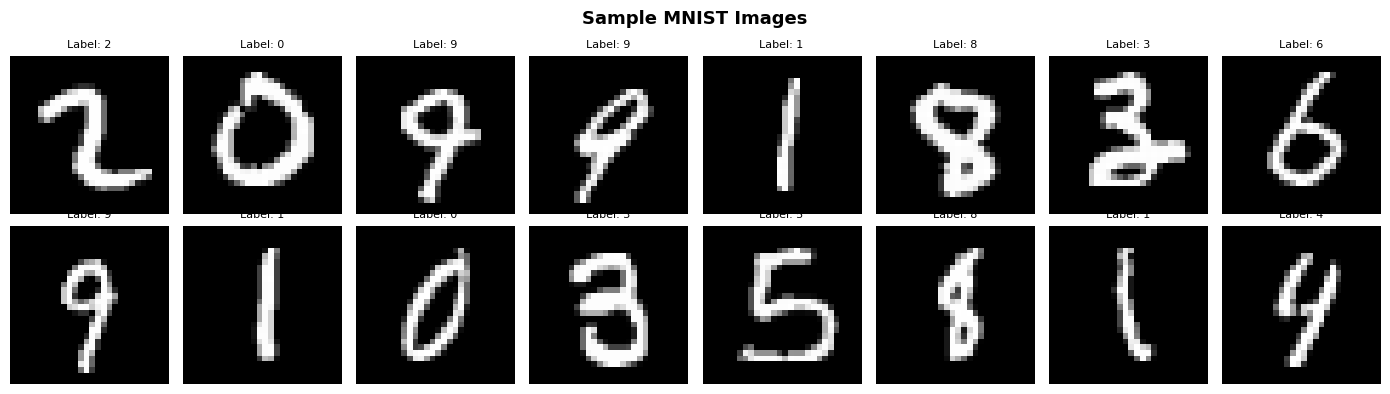

In [4]:
# ─────────────────────────────────────────────────────────────
# Visualise a batch of MNIST images
# ─────────────────────────────────────────────────────────────
examples = iter(train_loader)
images, labels = next(examples)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f'Label: {labels[i].item()}', fontsize=8)
    ax.axis('off')
plt.suptitle('Sample MNIST Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# ─────────────────────────────────────────────────────────────
# Utility functions shared across all problem statements
# ─────────────────────────────────────────────────────────────

def count_parameters(model):
    """Return total number of trainable parameters in a model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_one_epoch(model, loader, criterion, optimizer, clip=None):
    """
    Train model for one epoch.
    Args:
        model     : PyTorch model
        loader    : training DataLoader
        criterion : loss function
        optimizer : optimizer
        clip      : gradient clipping value (None = no clipping)
    Returns:
        avg_loss  : mean loss over all batches
        accuracy  : percentage accuracy over training set
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        # Reshape: (batch, 1, 28, 28) → (batch, 28, 28)
        images = images.squeeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        # Optional gradient clipping to prevent exploding gradients
        if clip:
            nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    return total_loss / total, 100.0 * correct / total


def evaluate(model, loader, criterion):
    """
    Evaluate model on a DataLoader (validation or test).
    Returns avg_loss and accuracy.
    """
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            images = images.squeeze(1)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * labels.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total   += labels.size(0)

    return total_loss / total, 100.0 * correct / total


def train_model(model, train_loader, val_loader, criterion, optimizer,
                num_epochs=10, clip=None, scheduler=None):
    """
    Full training loop with validation.
    Returns history dict with train/val loss and accuracy per epoch,
    plus total training time.
    """
    history = {'train_loss': [], 'train_acc': [],
               'val_loss':   [], 'val_acc':   []}
    start = time.time()

    for epoch in range(1, num_epochs + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, clip)
        v_loss, v_acc = evaluate(model, val_loader, criterion)

        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)

        if scheduler:
            scheduler.step(v_loss)

        print(f'Epoch [{epoch:02d}/{num_epochs}] '
              f'Train Loss: {t_loss:.4f} | Train Acc: {t_acc:.2f}% '
              f'| Val Loss: {v_loss:.4f} | Val Acc: {v_acc:.2f}%')

    elapsed = time.time() - start
    print(f'\nTraining complete in {elapsed:.1f}s  '
          f'({elapsed/num_epochs:.1f}s/epoch)')
    return history, elapsed


def plot_history(history, title='Training History'):
    """Plot loss and accuracy curves side by side."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history['train_loss'], label='Train Loss', color='steelblue')
    ax1.plot(history['val_loss'],   label='Val Loss',   color='coral')
    ax1.set_title('Loss Curve')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history['train_acc'], label='Train Acc', color='steelblue')
    ax2.plot(history['val_acc'],   label='Val Acc',   color='coral')
    ax2.set_title('Accuracy Curve')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(model, loader, class_names, title='Confusion Matrix'):
    """Compute and plot the confusion matrix for a model."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.squeeze(1).to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title, fontweight='bold')
    plt.tight_layout()
    plt.show()
    return all_labels, all_preds


# ─────────────────────────────────────────────────────────────
# Global results store for final comparison (Problem 7)
# ─────────────────────────────────────────────────────────────
results_summary = {}

CLASS_NAMES = [str(i) for i in range(10)]   # MNIST digit labels
NUM_CLASSES = 10
INPUT_SIZE  = 28   # features per time step (one row of pixels)
SEQ_LEN     = 28   # number of time steps  (rows in the image)
NUM_EPOCHS  = 10   # default training epochs (increase for better results)

print('Utility functions defined. Ready for training.')

Utility functions defined. Ready for training.


---
<a id='prob1'></a>
## Problem Statement 1 — Vanilla RNN

A Vanilla (Elman) RNN updates its hidden state as:

$$h_t = \tanh(W_{ih} x_t + W_{hh} h_{t-1} + b)$$

Tasks covered:
- **(a)** RNN from scratch + PyTorch RNN  
- **(b)** Vanishing gradient analysis  
- **(c)** Row-wise vs column-wise scanning  
- **(d)** Accuracy, loss curves, training time

In [6]:
# ─────────────────────────────────────────────────────────────
# Task (a) – Part 1: Vanilla RNN implemented FROM SCRATCH
# We manually unroll the recurrence without using nn.RNN
# ─────────────────────────────────────────────────────────────

class VanillaRNNScratch(nn.Module):
    """
    Manual (from-scratch) single-layer Vanilla RNN.
    Equation: h_t = tanh(x_t @ W_ih.T + h_{t-1} @ W_hh.T + b)
    """
    def __init__(self, input_size, hidden_size, num_classes):
        super(VanillaRNNScratch, self).__init__()
        self.hidden_size = hidden_size

        # Input-to-hidden weight matrix
        self.W_ih = nn.Parameter(torch.randn(hidden_size, input_size) * 0.01)
        # Hidden-to-hidden weight matrix (recurrent weights)
        self.W_hh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.01)
        # Bias term
        self.b_h  = nn.Parameter(torch.zeros(hidden_size))
        # Output (classification) layer
        self.fc   = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        """
        x shape: (batch, seq_len, input_size)
        Manually unroll the sequence over time steps.
        """
        batch_size = x.size(0)
        # Initialise hidden state to zeros
        h = torch.zeros(batch_size, self.hidden_size).to(x.device)

        for t in range(x.size(1)):  # iterate over 28 time steps
            x_t = x[:, t, :]        # (batch, input_size)
            # RNN recurrence formula
            h = torch.tanh(x_t @ self.W_ih.T + h @ self.W_hh.T + self.b_h)

        # Use the final hidden state for classification
        return self.fc(h)


print('VanillaRNNScratch defined.')

VanillaRNNScratch defined.


In [7]:
# ─────────────────────────────────────────────────────────────
# Task (a) – Part 2: Vanilla RNN using PyTorch nn.RNN
# Experiment with num_layers ∈ {1, 2, 3} and
# hidden_size ∈ {64, 128, 256}
# ─────────────────────────────────────────────────────────────

class VanillaRNN(nn.Module):
    """
    Configurable Vanilla RNN using PyTorch's built-in nn.RNN.
    Supports stacking multiple RNN layers.
    """
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.0):
        super(VanillaRNN, self).__init__()
        self.rnn = nn.RNN(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,        # input shape: (batch, seq, features)
            nonlinearity= 'tanh',
            dropout     = dropout if num_layers > 1 else 0.0
        )
        # Final linear classifier on last hidden state
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (batch, seq_len=28, input_size=28)
        out, _ = self.rnn(x)    # out: (batch, seq_len, hidden_size)
        out = self.fc(out[:, -1, :])  # take last time step
        return out


print('VanillaRNN (PyTorch) defined.')

VanillaRNN (PyTorch) defined.


In [8]:
# ─────────────────────────────────────────────────────────────
# Train from-scratch RNN as a baseline
# ─────────────────────────────────────────────────────────────
print('=' * 55)
print('Training Vanilla RNN (from scratch)')
print('=' * 55)

rnn_scratch = VanillaRNNScratch(INPUT_SIZE, hidden_size=128, num_classes=NUM_CLASSES).to(device)
criterion   = nn.CrossEntropyLoss()
optimizer   = optim.Adam(rnn_scratch.parameters(), lr=0.001)

print(f'Parameters: {count_parameters(rnn_scratch):,}')

hist_rnn_scratch, t_scratch = train_model(
    rnn_scratch, train_loader, val_loader,
    criterion, optimizer, num_epochs=NUM_EPOCHS
)

_, test_acc_scratch = evaluate(rnn_scratch, test_loader, criterion)
print(f'\nTest Accuracy (From Scratch): {test_acc_scratch:.2f}%')

Training Vanilla RNN (from scratch)
Parameters: 21,386
Epoch [01/10] Train Loss: 1.1345 | Train Acc: 59.14% | Val Loss: 0.6254 | Val Acc: 79.38%
Epoch [02/10] Train Loss: 0.5041 | Train Acc: 84.14% | Val Loss: 0.4464 | Val Acc: 86.17%
Epoch [03/10] Train Loss: 0.3429 | Train Acc: 89.65% | Val Loss: 0.3089 | Val Acc: 91.07%
Epoch [04/10] Train Loss: 0.2723 | Train Acc: 92.00% | Val Loss: 0.2546 | Val Acc: 92.72%
Epoch [05/10] Train Loss: 0.2257 | Train Acc: 93.55% | Val Loss: 0.2456 | Val Acc: 92.72%
Epoch [06/10] Train Loss: 0.1948 | Train Acc: 94.40% | Val Loss: 0.2183 | Val Acc: 93.68%
Epoch [07/10] Train Loss: 0.1832 | Train Acc: 94.82% | Val Loss: 0.1878 | Val Acc: 94.48%
Epoch [08/10] Train Loss: 0.1676 | Train Acc: 95.30% | Val Loss: 0.1852 | Val Acc: 94.23%
Epoch [09/10] Train Loss: 0.1553 | Train Acc: 95.65% | Val Loss: 0.2114 | Val Acc: 94.08%
Epoch [10/10] Train Loss: 0.1475 | Train Acc: 95.83% | Val Loss: 0.1579 | Val Acc: 95.43%

Training complete in 119.0s  (11.9s/epoch)



In [9]:
# ─────────────────────────────────────────────────────────────
# Train PyTorch RNN with varying layers and hidden units
# Task (a) + Task (d)
# ─────────────────────────────────────────────────────────────

rnn_configs = [
    {'num_layers': 1, 'hidden_size': 64},
    {'num_layers': 1, 'hidden_size': 128},
    {'num_layers': 2, 'hidden_size': 128},
    {'num_layers': 3, 'hidden_size': 128},
    {'num_layers': 1, 'hidden_size': 256},
]

rnn_results = {}

for cfg in rnn_configs:
    key = f"RNN_L{cfg['num_layers']}_H{cfg['hidden_size']}"
    print(f'\n{"─"*50}')
    print(f'Config: {key}')
    print(f'{"─"*50}')

    model = VanillaRNN(INPUT_SIZE, cfg['hidden_size'],
                       cfg['num_layers'], NUM_CLASSES).to(device)
    opt   = optim.Adam(model.parameters(), lr=0.001)

    print(f'Parameters: {count_parameters(model):,}')
    hist, elapsed = train_model(model, train_loader, val_loader,
                                criterion, opt, num_epochs=NUM_EPOCHS)
    _, test_acc = evaluate(model, test_loader, criterion)

    rnn_results[key] = {
        'model': model, 'history': hist,
        'test_acc': test_acc, 'time': elapsed,
        'params': count_parameters(model)
    }
    print(f'Test Accuracy: {test_acc:.2f}%')

# Store best RNN result for final comparison
best_rnn_key = max(rnn_results, key=lambda k: rnn_results[k]['test_acc'])
results_summary['Vanilla RNN'] = rnn_results[best_rnn_key]


──────────────────────────────────────────────────
Config: RNN_L1_H64
──────────────────────────────────────────────────
Parameters: 6,666
Epoch [01/10] Train Loss: 0.9830 | Train Acc: 66.28% | Val Loss: 0.5256 | Val Acc: 84.15%
Epoch [02/10] Train Loss: 0.4220 | Train Acc: 87.72% | Val Loss: 0.3471 | Val Acc: 89.80%
Epoch [03/10] Train Loss: 0.3198 | Train Acc: 90.77% | Val Loss: 0.3298 | Val Acc: 90.48%
Epoch [04/10] Train Loss: 0.2655 | Train Acc: 92.41% | Val Loss: 0.3408 | Val Acc: 89.88%
Epoch [05/10] Train Loss: 0.2400 | Train Acc: 93.14% | Val Loss: 0.2801 | Val Acc: 92.05%
Epoch [06/10] Train Loss: 0.2186 | Train Acc: 93.74% | Val Loss: 0.2025 | Val Acc: 94.27%
Epoch [07/10] Train Loss: 0.2038 | Train Acc: 94.13% | Val Loss: 0.2090 | Val Acc: 93.75%
Epoch [08/10] Train Loss: 0.1939 | Train Acc: 94.54% | Val Loss: 0.2054 | Val Acc: 94.27%
Epoch [09/10] Train Loss: 0.1792 | Train Acc: 94.93% | Val Loss: 0.2575 | Val Acc: 92.80%
Epoch [10/10] Train Loss: 0.1761 | Train Acc: 94.8

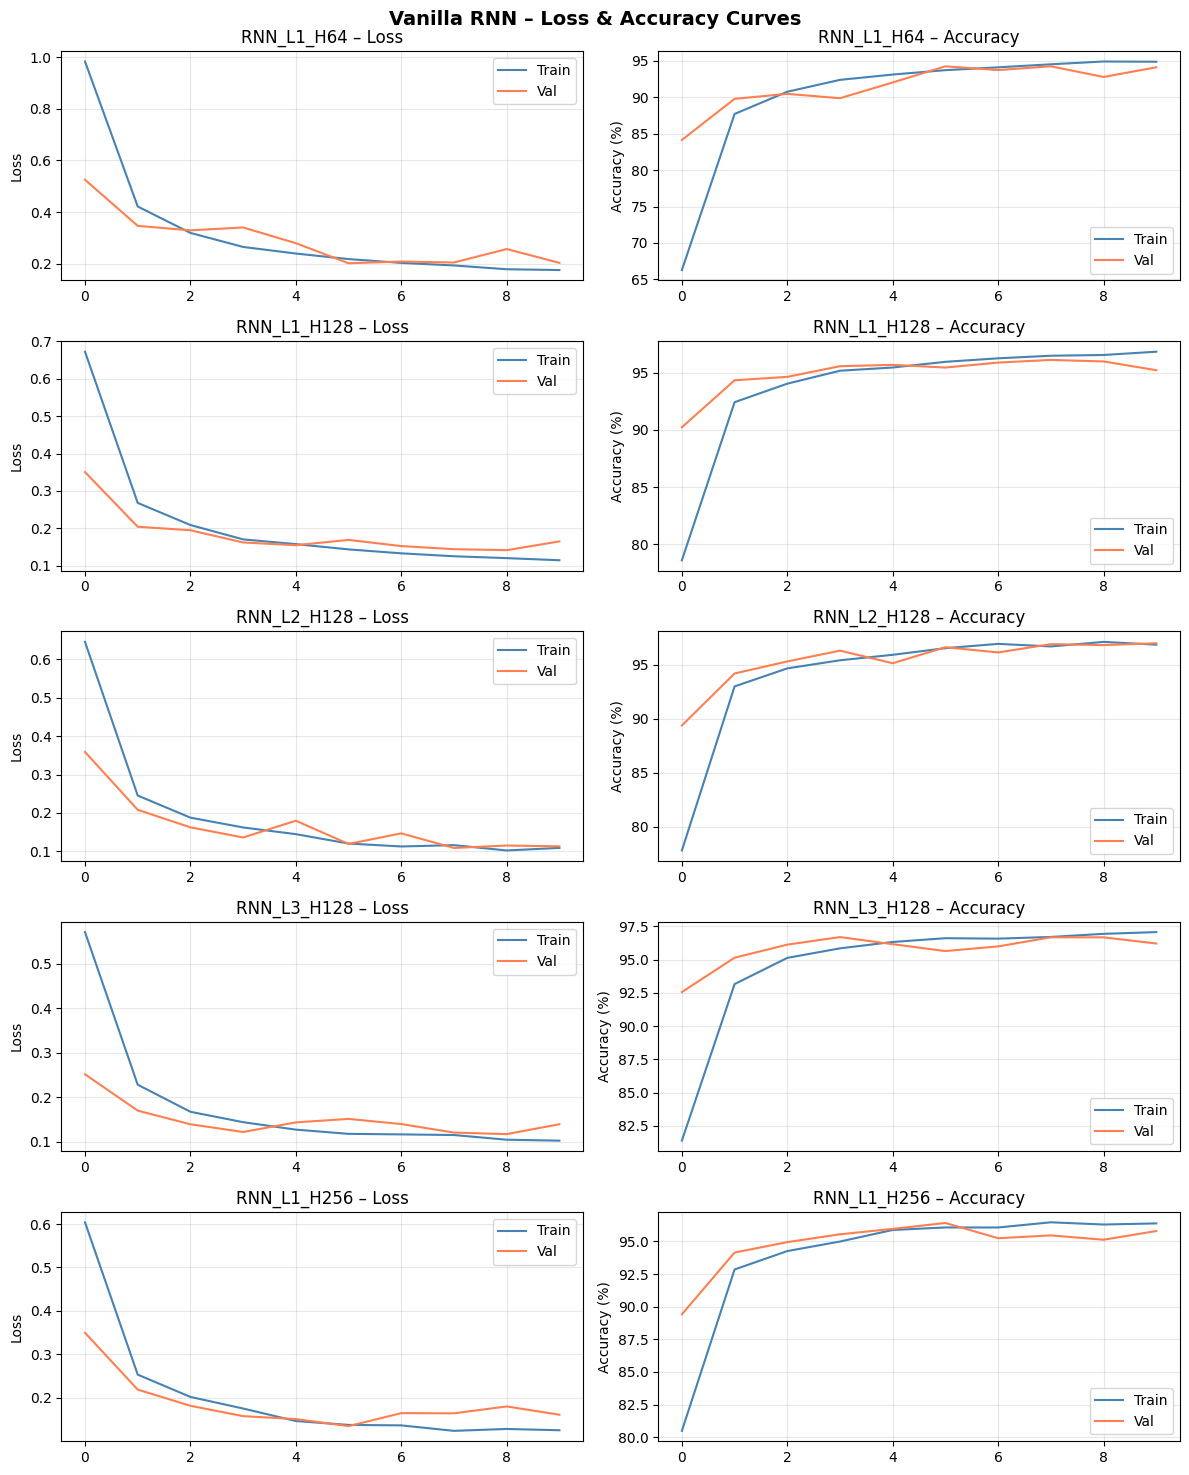

Config                        Params   Test Acc   Time (s)
──────────────────────────────────────────────────────────
RNN_L1_H64                     6,666     94.93%      122.8
RNN_L1_H128                   21,514     95.90%      118.8
RNN_L2_H128                   54,538     97.03%      183.5
RNN_L3_H128                   87,562     96.23%      251.8
RNN_L1_H256                   75,786     96.01%      171.5


In [10]:
# ─────────────────────────────────────────────────────────────
# Task (d) – Plot loss and accuracy curves for each RNN config
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(len(rnn_results), 2,
                         figsize=(12, 3 * len(rnn_results)))

for i, (key, res) in enumerate(rnn_results.items()):
    h = res['history']
    axes[i, 0].plot(h['train_loss'], label='Train', color='steelblue')
    axes[i, 0].plot(h['val_loss'],   label='Val',   color='coral')
    axes[i, 0].set_title(f'{key} – Loss')
    axes[i, 0].set_ylabel('Loss')
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].plot(h['train_acc'], label='Train', color='steelblue')
    axes[i, 1].plot(h['val_acc'],   label='Val',   color='coral')
    axes[i, 1].set_title(f'{key} – Accuracy')
    axes[i, 1].set_ylabel('Accuracy (%)')
    axes[i, 1].legend()
    axes[i, 1].grid(True, alpha=0.3)

plt.suptitle('Vanilla RNN – Loss & Accuracy Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary table
print(f'{"Config":<25} {"Params":>10} {"Test Acc":>10} {"Time (s)":>10}')
print('─' * 58)
for k, v in rnn_results.items():
    print(f'{k:<25} {v["params"]:>10,} {v["test_acc"]:>9.2f}% {v["time"]:>10.1f}')

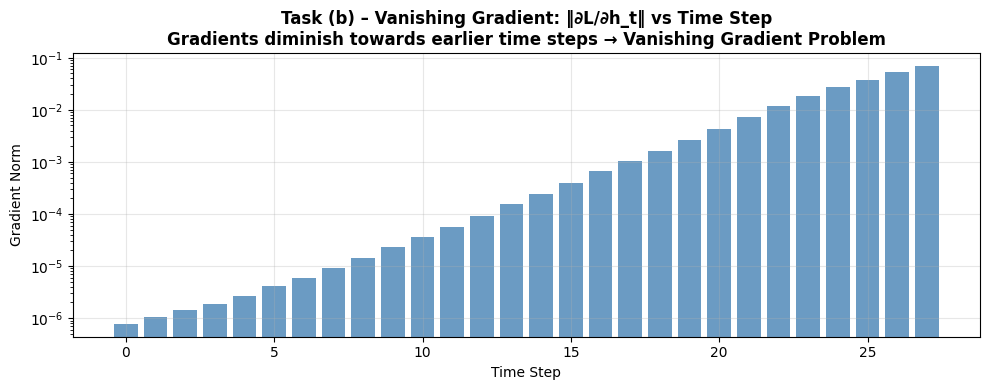

Gradient at last time step : 0.069248
Gradient at first time step: 0.000001


In [11]:
# ─────────────────────────────────────────────────────────────
# Task (b) – Vanishing Gradient Analysis
# We train for one step and capture the gradient magnitude
# at each time step by registering hooks on hidden states
# ─────────────────────────────────────────────────────────────

class VanillaRNNGradTrack(nn.Module):
    """
    RNN variant that stores gradient norms at each time step
    to demonstrate vanishing gradients.
    """
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.hidden_size  = hidden_size
        self.W_ih = nn.Parameter(torch.randn(hidden_size, input_size)  * 0.1)
        self.W_hh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.1)
        self.b_h  = nn.Parameter(torch.zeros(hidden_size))
        self.fc   = nn.Linear(hidden_size, num_classes)
        self.grad_norms = []   # list to store ‖∂L/∂h_t‖

    def forward(self, x):
        self.grad_norms = []
        batch = x.size(0)
        h = torch.zeros(batch, self.hidden_size, requires_grad=True).to(x.device)
        hidden_states = []

        for t in range(x.size(1)):
            x_t = x[:, t, :]
            h = torch.tanh(x_t @ self.W_ih.T + h @ self.W_hh.T + self.b_h)
            hidden_states.append(h)

        # Register hook on each hidden state to capture gradient norm
        for h_t in hidden_states:
            h_t.register_hook(lambda grad: self.grad_norms.append(grad.norm().item()))

        return self.fc(hidden_states[-1])


grad_model = VanillaRNNGradTrack(INPUT_SIZE, hidden_size=64, num_classes=NUM_CLASSES).to(device)
grad_opt   = optim.SGD(grad_model.parameters(), lr=0.01)

# Forward + backward pass on a single batch
sample_images, sample_labels = next(iter(train_loader))
sample_images = sample_images.squeeze(1).to(device)
sample_labels = sample_labels.to(device)

grad_opt.zero_grad()
output = grad_model(sample_images)
loss   = criterion(output, sample_labels)
loss.backward()

# Gradient norms are filled in reverse (last → first time step)
grad_norms = list(reversed(grad_model.grad_norms))

plt.figure(figsize=(10, 4))
plt.bar(range(len(grad_norms)), grad_norms, color='steelblue', alpha=0.8)
plt.xlabel('Time Step')
plt.ylabel('Gradient Norm')
plt.title('Task (b) – Vanishing Gradient: ‖∂L/∂h_t‖ vs Time Step\n'
          'Gradients diminish towards earlier time steps → Vanishing Gradient Problem',
          fontweight='bold')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Gradient at last time step :', f'{grad_norms[-1]:.6f}')
print('Gradient at first time step:', f'{grad_norms[0]:.6f}')


── Row-wise Scanning ──
Epoch [01/10] Train Loss: 0.6852 | Val Acc: 89.55%
Epoch [02/10] Train Loss: 0.2675 | Val Acc: 93.98%
Epoch [03/10] Train Loss: 0.2121 | Val Acc: 94.80%
Epoch [04/10] Train Loss: 0.1814 | Val Acc: 95.15%
Epoch [05/10] Train Loss: 0.1562 | Val Acc: 95.33%
Epoch [06/10] Train Loss: 0.1430 | Val Acc: 95.67%
Epoch [07/10] Train Loss: 0.1372 | Val Acc: 96.15%
Epoch [08/10] Train Loss: 0.1221 | Val Acc: 96.47%
Epoch [09/10] Train Loss: 0.1184 | Val Acc: 96.20%
Epoch [10/10] Train Loss: 0.1128 | Val Acc: 95.87%
Done in 119.7s

── Column-wise Scanning ──
Epoch [01/10] Train Loss: 0.7152 | Val Acc: 87.62%
Epoch [02/10] Train Loss: 0.3250 | Val Acc: 92.45%
Epoch [03/10] Train Loss: 0.2610 | Val Acc: 93.93%
Epoch [04/10] Train Loss: 0.2207 | Val Acc: 94.42%
Epoch [05/10] Train Loss: 0.2011 | Val Acc: 94.33%
Epoch [06/10] Train Loss: 0.1779 | Val Acc: 94.68%
Epoch [07/10] Train Loss: 0.1816 | Val Acc: 95.05%
Epoch [08/10] Train Loss: 0.1579 | Val Acc: 93.60%
Epoch [09/10] 

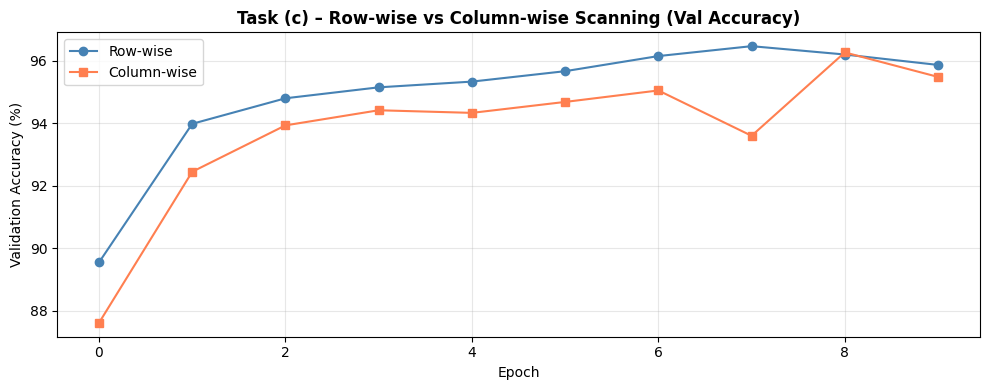

Row-wise    final val acc: 95.87%
Column-wise final val acc: 95.48%


In [12]:
# ─────────────────────────────────────────────────────────────
# Task (c) – Row-wise vs Column-wise Image Scanning
# Row-wise   : sequence along rows    → (batch, 28, 28)
# Column-wise: sequence along columns → (batch, 28, 28) transposed
# ─────────────────────────────────────────────────────────────

def train_model_with_transform(model, train_loader, val_loader,
                                criterion, optimizer, num_epochs, transpose=False):
    """
    Same as train_model but optionally transposes the image tensor
    to switch between row-wise and column-wise scanning.
    """
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    start   = time.time()

    for epoch in range(1, num_epochs + 1):
        # ── Training ──
        model.train()
        t_loss, correct, total = 0.0, 0, 0
        for imgs, lbls in train_loader:
            imgs = imgs.squeeze(1).to(device)
            if transpose:
                imgs = imgs.transpose(1, 2)   # swap rows and columns
            lbls = lbls.to(device)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()
            t_loss  += loss.item() * lbls.size(0)
            correct += out.max(1)[1].eq(lbls).sum().item()
            total   += lbls.size(0)
        history['train_loss'].append(t_loss / total)
        history['train_acc'].append(100. * correct / total)

        # ── Validation ──
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs = imgs.squeeze(1).to(device)
                if transpose:
                    imgs = imgs.transpose(1, 2)
                lbls = lbls.to(device)
                out  = model(imgs)
                loss = criterion(out, lbls)
                v_loss    += loss.item() * lbls.size(0)
                v_correct += out.max(1)[1].eq(lbls).sum().item()
                v_total   += lbls.size(0)
        history['val_loss'].append(v_loss / v_total)
        history['val_acc'].append(100. * v_correct / v_total)

        print(f'Epoch [{epoch:02d}/{num_epochs}] '
              f'Train Loss: {history["train_loss"][-1]:.4f} '
              f'| Val Acc: {history["val_acc"][-1]:.2f}%')

    elapsed = time.time() - start
    print(f'Done in {elapsed:.1f}s')
    return history, elapsed


# ── Row-wise model ──
print('\n── Row-wise Scanning ──')
rnn_row = VanillaRNN(INPUT_SIZE, 128, 1, NUM_CLASSES).to(device)
opt_row = optim.Adam(rnn_row.parameters(), lr=0.001)
hist_row, _ = train_model_with_transform(
    rnn_row, train_loader, val_loader, criterion, opt_row, NUM_EPOCHS, transpose=False)

# ── Column-wise model ──
print('\n── Column-wise Scanning ──')
rnn_col = VanillaRNN(INPUT_SIZE, 128, 1, NUM_CLASSES).to(device)
opt_col = optim.Adam(rnn_col.parameters(), lr=0.001)
hist_col, _ = train_model_with_transform(
    rnn_col, train_loader, val_loader, criterion, opt_col, NUM_EPOCHS, transpose=True)

# ── Plot comparison ──
plt.figure(figsize=(10, 4))
plt.plot(hist_row['val_acc'], label='Row-wise',    color='steelblue', marker='o')
plt.plot(hist_col['val_acc'], label='Column-wise', color='coral',     marker='s')
plt.title('Task (c) – Row-wise vs Column-wise Scanning (Val Accuracy)', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Row-wise    final val acc: {hist_row["val_acc"][-1]:.2f}%')
print(f'Column-wise final val acc: {hist_col["val_acc"][-1]:.2f}%')

---
<a id='prob2'></a>
## Problem Statement 2 — LSTM

LSTM gates overcome the vanishing gradient problem:

$$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f) \quad\text{(Forget Gate)}$$
$$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i) \quad\text{(Input Gate)}$$
$$\tilde{C}_t = \tanh(W_C [h_{t-1}, x_t] + b_C) \quad\text{(Candidate)}$$
$$C_t = f_t \cdot C_{t-1} + i_t \cdot \tilde{C}_t \quad\text{(Cell State)}$$
$$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o) \quad\text{(Output Gate)}$$
$$h_t = o_t \cdot \tanh(C_t)$$

Tasks: (e) Single & stacked LSTM | (f) Gate activations | (g) Hidden sizes | (h) Dropout | (i) Compare with RNN

In [13]:
# ─────────────────────────────────────────────────────────────
# Task (e) – Single-layer and multi-layer LSTM
# ─────────────────────────────────────────────────────────────

class LSTMModel(nn.Module):
    """
    Configurable stacked LSTM model.
    Supports variable layers, hidden units, and dropout.
    """
    def __init__(self, input_size, hidden_size, num_layers,
                 num_classes, dropout=0.0):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )
        # Optional dropout after LSTM output
        self.dropout = nn.Dropout(p=dropout)
        self.fc      = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)   # out: (batch, seq, hidden)
        # Take the output at the last time step
        out = self.dropout(out[:, -1, :])
        return self.fc(out)


print('LSTMModel defined.')

LSTMModel defined.


In [14]:
# ─────────────────────────────────────────────────────────────
# Task (g) – Experiment with hidden units: 32, 64, 128, 256
# ─────────────────────────────────────────────────────────────

lstm_configs = [
    {'num_layers': 1, 'hidden_size': 32,  'dropout': 0.0},
    {'num_layers': 1, 'hidden_size': 64,  'dropout': 0.0},
    {'num_layers': 1, 'hidden_size': 128, 'dropout': 0.0},
    {'num_layers': 1, 'hidden_size': 256, 'dropout': 0.0},
    {'num_layers': 2, 'hidden_size': 128, 'dropout': 0.2},  # Task (h)
    {'num_layers': 2, 'hidden_size': 128, 'dropout': 0.3},
    {'num_layers': 2, 'hidden_size': 128, 'dropout': 0.5},
]

lstm_results = {}

for cfg in lstm_configs:
    key = f"LSTM_L{cfg['num_layers']}_H{cfg['hidden_size']}_D{cfg['dropout']}"
    print(f'\n{"─"*55}')
    print(f'Config: {key}')
    print(f'{"─"*55}')

    model = LSTMModel(INPUT_SIZE, cfg['hidden_size'],
                      cfg['num_layers'], NUM_CLASSES,
                      dropout=cfg['dropout']).to(device)
    opt   = optim.Adam(model.parameters(), lr=0.001)

    print(f'Parameters: {count_parameters(model):,}')
    hist, elapsed = train_model(model, train_loader, val_loader,
                                criterion, opt, num_epochs=NUM_EPOCHS)
    _, test_acc = evaluate(model, test_loader, criterion)

    lstm_results[key] = {
        'model': model, 'history': hist,
        'test_acc': test_acc, 'time': elapsed,
        'params': count_parameters(model)
    }
    print(f'Test Accuracy: {test_acc:.2f}%')

# Save best LSTM for Problem 7
best_lstm_key = max(lstm_results, key=lambda k: lstm_results[k]['test_acc'])
results_summary['LSTM'] = lstm_results[best_lstm_key]
best_lstm_model = lstm_results[best_lstm_key]['model']


───────────────────────────────────────────────────────
Config: LSTM_L1_H32_D0.0
───────────────────────────────────────────────────────
Parameters: 8,266
Epoch [01/10] Train Loss: 0.8407 | Train Acc: 72.44% | Val Loss: 0.3275 | Val Acc: 90.35%
Epoch [02/10] Train Loss: 0.2498 | Train Acc: 92.71% | Val Loss: 0.2026 | Val Acc: 94.03%
Epoch [03/10] Train Loss: 0.1679 | Train Acc: 95.06% | Val Loss: 0.1786 | Val Acc: 94.58%
Epoch [04/10] Train Loss: 0.1284 | Train Acc: 96.25% | Val Loss: 0.1320 | Val Acc: 96.35%
Epoch [05/10] Train Loss: 0.1090 | Train Acc: 96.83% | Val Loss: 0.1207 | Val Acc: 96.52%
Epoch [06/10] Train Loss: 0.0955 | Train Acc: 97.21% | Val Loss: 0.1143 | Val Acc: 96.77%
Epoch [07/10] Train Loss: 0.0867 | Train Acc: 97.46% | Val Loss: 0.1047 | Val Acc: 96.90%
Epoch [08/10] Train Loss: 0.0749 | Train Acc: 97.79% | Val Loss: 0.0902 | Val Acc: 97.40%
Epoch [09/10] Train Loss: 0.0698 | Train Acc: 97.95% | Val Loss: 0.0905 | Val Acc: 97.48%
Epoch [10/10] Train Loss: 0.0618 |

Quick training of gate visualiser model (3 epochs)…
Done.


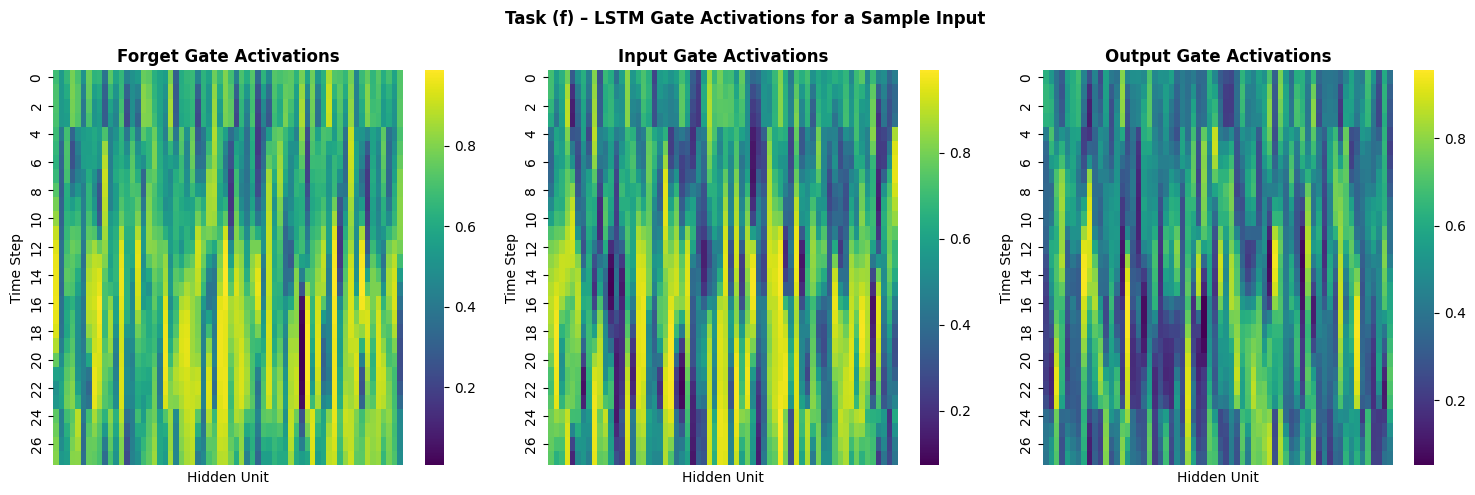

In [15]:
# ─────────────────────────────────────────────────────────────
# Task (f) – Visualise LSTM gate activations for sample inputs
# We hook into the LSTM cell to extract gate values
# ─────────────────────────────────────────────────────────────

class LSTMGateVisualizer(nn.Module):
    """
    LSTM that manually computes gate activations so we can
    store and visualise forget, input, and output gates.
    """
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.hidden_size  = hidden_size
        self.lstm_cell    = nn.LSTMCell(input_size, hidden_size)
        self.fc           = nn.Linear(hidden_size, num_classes)

        # Storage for gate activations (filled during forward)
        self.forget_gates = []
        self.input_gates  = []
        self.output_gates = []

    def forward(self, x):
        self.forget_gates, self.input_gates, self.output_gates = [], [], []
        batch = x.size(0)
        h = torch.zeros(batch, self.hidden_size).to(x.device)
        c = torch.zeros(batch, self.hidden_size).to(x.device)

        for t in range(x.size(1)):
            x_t    = x[:, t, :]
            h, c   = self.lstm_cell(x_t, (h, c))

            # Manually recompute gates for visualisation
            combined = torch.cat([h, x_t], dim=1)
            gates    = self.lstm_cell.weight_ih @ x_t.T + \
                       self.lstm_cell.weight_hh @ h.T
            gates    = gates.T + self.lstm_cell.bias_ih + self.lstm_cell.bias_hh
            hs       = self.hidden_size

            f = torch.sigmoid(gates[:, hs:2*hs])
            i = torch.sigmoid(gates[:, :hs])
            o = torch.sigmoid(gates[:, 2*hs:3*hs])

            # Save mean activation across batch for one sample
            self.forget_gates.append(f[0].detach().cpu().numpy())
            self.input_gates.append(i[0].detach().cpu().numpy())
            self.output_gates.append(o[0].detach().cpu().numpy())

        return self.fc(h)


gate_model = LSTMGateVisualizer(INPUT_SIZE, hidden_size=64, num_classes=NUM_CLASSES).to(device)
gate_opt   = optim.Adam(gate_model.parameters(), lr=0.001)

# Quick train for 3 epochs so gates are meaningful
print('Quick training of gate visualiser model (3 epochs)…')
for epoch in range(3):
    train_one_epoch(gate_model, train_loader, criterion, gate_opt)
print('Done.')

# Forward pass on one sample to capture gates
gate_model.eval()
sample = sample_images[0:1]   # shape (1, 28, 28)
with torch.no_grad():
    _ = gate_model(sample)

# Plot heatmaps of gate activations over time steps
import numpy as np
fg = np.array(gate_model.forget_gates)   # (28, hidden)
ig = np.array(gate_model.input_gates)
og = np.array(gate_model.output_gates)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, data, name in zip(axes, [fg, ig, og], ['Forget Gate', 'Input Gate', 'Output Gate']):
    sns.heatmap(data, ax=ax, cmap='viridis', cbar=True,
                xticklabels=False)
    ax.set_title(f'{name} Activations', fontweight='bold')
    ax.set_xlabel('Hidden Unit')
    ax.set_ylabel('Time Step')

plt.suptitle('Task (f) – LSTM Gate Activations for a Sample Input', fontweight='bold')
plt.tight_layout()
plt.show()

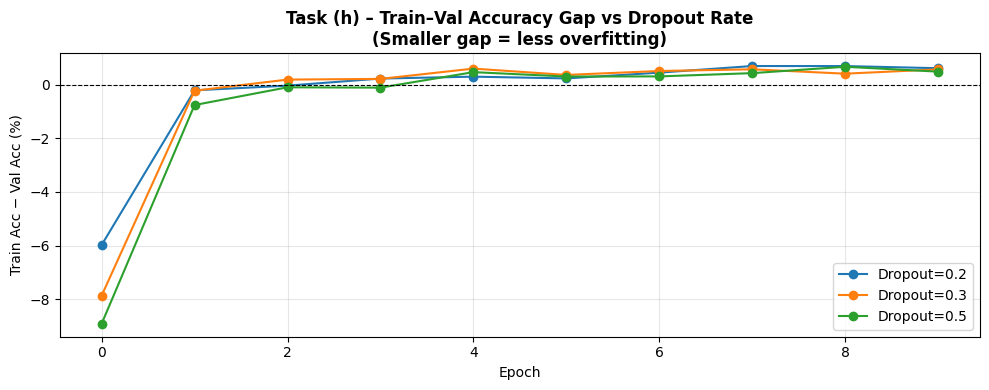

In [16]:
# ─────────────────────────────────────────────────────────────
# Task (h) – Dropout analysis: overfitting comparison
# ─────────────────────────────────────────────────────────────

dropout_keys = [k for k in lstm_results if 'L2' in k]  # configs with 2 layers

plt.figure(figsize=(10, 4))
for k in dropout_keys:
    h   = lstm_results[k]['history']
    gap = [tr - va for tr, va in zip(h['train_acc'], h['val_acc'])]
    d   = float(k.split('_D')[1])
    plt.plot(gap, label=f'Dropout={d}', marker='o')

plt.title('Task (h) – Train–Val Accuracy Gap vs Dropout Rate\n'
          '(Smaller gap = less overfitting)', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Train Acc − Val Acc (%)')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

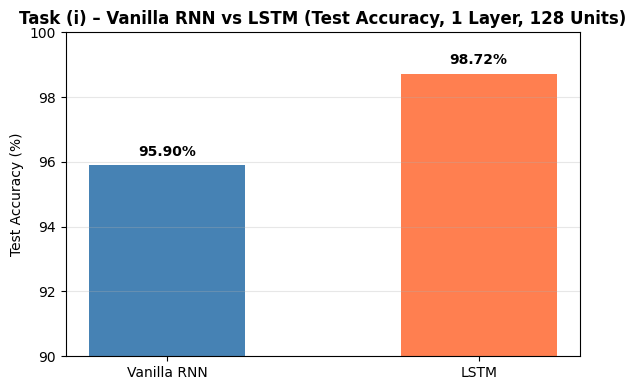

In [17]:
# ─────────────────────────────────────────────────────────────
# Task (i) – Compare LSTM vs Vanilla RNN
# ─────────────────────────────────────────────────────────────

# Pick a matching config: 1 layer, 128 hidden units
rnn_acc  = rnn_results.get('RNN_L1_H128',  rnn_results[list(rnn_results.keys())[1]])['test_acc']
lstm_acc = lstm_results['LSTM_L1_H128_D0.0']['test_acc']

models_cmp = ['Vanilla RNN', 'LSTM']
accs_cmp   = [rnn_acc, lstm_acc]

plt.figure(figsize=(6, 4))
bars = plt.bar(models_cmp, accs_cmp, color=['steelblue', 'coral'], width=0.5)
for bar, acc in zip(bars, accs_cmp):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')
plt.title('Task (i) – Vanilla RNN vs LSTM (Test Accuracy, 1 Layer, 128 Units)',
          fontweight='bold')
plt.ylabel('Test Accuracy (%)')
plt.ylim(90, 100)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
<a id='prob3'></a>
## Problem Statement 3 — GRU

GRU simplifies LSTM with two gates:

$$r_t = \sigma(W_r [h_{t-1}, x_t]) \quad\text{(Reset Gate)}$$
$$z_t = \sigma(W_z [h_{t-1}, x_t]) \quad\text{(Update Gate)}$$
$$\tilde{h}_t = \tanh(W [r_t \odot h_{t-1}, x_t])$$
$$h_t = (1 - z_t) \cdot h_{t-1} + z_t \cdot \tilde{h}_t$$

Tasks: (j) GRU vs LSTM | (k) FLOPs & memory | (l) Stacked GRU | (m) When to prefer GRU

In [18]:
# ─────────────────────────────────────────────────────────────
# GRU model definition
# ─────────────────────────────────────────────────────────────

class GRUModel(nn.Module):
    """
    Configurable GRU model supporting stacked layers.
    Uses PyTorch nn.GRU internally.
    """
    def __init__(self, input_size, hidden_size, num_layers,
                 num_classes, dropout=0.0):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(p=dropout)
        self.fc      = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.gru(x)
        out    = self.dropout(out[:, -1, :])
        return self.fc(out)


print('GRUModel defined.')

GRUModel defined.


In [19]:
# ─────────────────────────────────────────────────────────────
# Task (l) – Stacked GRU: 1, 2, 3 layers
# Task (j) – Train and compare with LSTM
# ─────────────────────────────────────────────────────────────

gru_configs = [
    {'num_layers': 1, 'hidden_size': 128, 'dropout': 0.0},
    {'num_layers': 2, 'hidden_size': 128, 'dropout': 0.2},
    {'num_layers': 3, 'hidden_size': 128, 'dropout': 0.2},
]

gru_results = {}

for cfg in gru_configs:
    key = f"GRU_L{cfg['num_layers']}_H{cfg['hidden_size']}"
    print(f'\n{"─"*50}')
    print(f'Config: {key}')
    print(f'{"─"*50}')

    model = GRUModel(INPUT_SIZE, cfg['hidden_size'],
                     cfg['num_layers'], NUM_CLASSES,
                     dropout=cfg['dropout']).to(device)
    opt   = optim.Adam(model.parameters(), lr=0.001)

    print(f'Parameters: {count_parameters(model):,}')
    hist, elapsed = train_model(model, train_loader, val_loader,
                                criterion, opt, num_epochs=NUM_EPOCHS)
    _, test_acc = evaluate(model, test_loader, criterion)

    gru_results[key] = {
        'model': model, 'history': hist,
        'test_acc': test_acc, 'time': elapsed,
        'params': count_parameters(model)
    }
    print(f'Test Accuracy: {test_acc:.2f}%')

best_gru_key = max(gru_results, key=lambda k: gru_results[k]['test_acc'])
results_summary['GRU'] = gru_results[best_gru_key]


──────────────────────────────────────────────────
Config: GRU_L1_H128
──────────────────────────────────────────────────
Parameters: 61,962
Epoch [01/10] Train Loss: 0.4105 | Train Acc: 86.69% | Val Loss: 0.1200 | Val Acc: 96.45%
Epoch [02/10] Train Loss: 0.0886 | Train Acc: 97.31% | Val Loss: 0.0839 | Val Acc: 97.52%
Epoch [03/10] Train Loss: 0.0598 | Train Acc: 98.24% | Val Loss: 0.0623 | Val Acc: 98.08%
Epoch [04/10] Train Loss: 0.0473 | Train Acc: 98.54% | Val Loss: 0.0570 | Val Acc: 98.23%
Epoch [05/10] Train Loss: 0.0371 | Train Acc: 98.87% | Val Loss: 0.0529 | Val Acc: 98.48%
Epoch [06/10] Train Loss: 0.0304 | Train Acc: 99.05% | Val Loss: 0.0509 | Val Acc: 98.43%
Epoch [07/10] Train Loss: 0.0260 | Train Acc: 99.18% | Val Loss: 0.0469 | Val Acc: 98.55%
Epoch [08/10] Train Loss: 0.0214 | Train Acc: 99.32% | Val Loss: 0.0568 | Val Acc: 98.40%
Epoch [09/10] Train Loss: 0.0203 | Train Acc: 99.35% | Val Loss: 0.0472 | Val Acc: 98.72%
Epoch [10/10] Train Loss: 0.0158 | Train Acc: 99

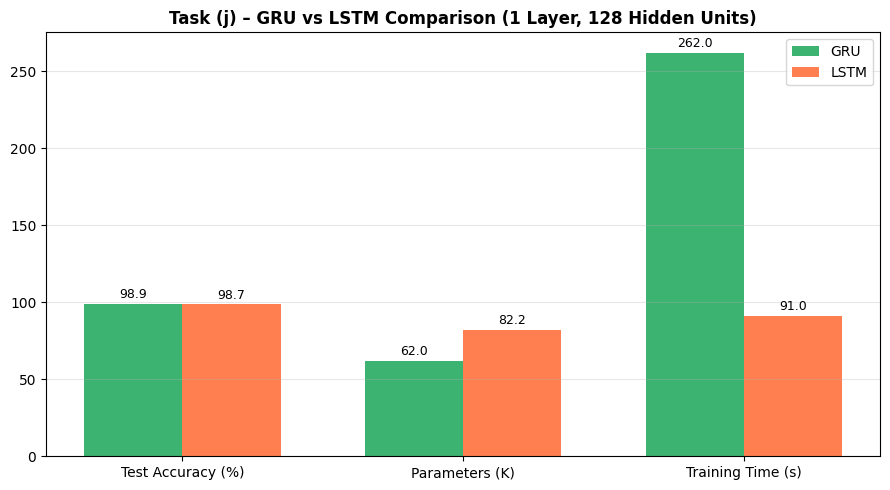

In [20]:
# ─────────────────────────────────────────────────────────────
# Task (j) – Compare GRU vs LSTM: accuracy, time, parameters
# ─────────────────────────────────────────────────────────────

gru_1l  = gru_results['GRU_L1_H128']
lstm_1l = lstm_results['LSTM_L1_H128_D0.0']

categories = ['Test Accuracy (%)', 'Parameters', 'Training Time (s)']
gru_vals   = [gru_1l['test_acc'], gru_1l['params'] / 1e3, gru_1l['time']]
lstm_vals  = [lstm_1l['test_acc'], lstm_1l['params'] / 1e3, lstm_1l['time']]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
rects1 = ax.bar(x - width/2, gru_vals,  width, label='GRU',  color='mediumseagreen')
rects2 = ax.bar(x + width/2, lstm_vals, width, label='LSTM', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(['Test Accuracy (%)', 'Parameters (K)', 'Training Time (s)'])
ax.legend()
ax.set_title('Task (j) – GRU vs LSTM Comparison (1 Layer, 128 Hidden Units)',
             fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

for rect in rects1:
    ax.annotate(f'{rect.get_height():.1f}',
                xy=(rect.get_x() + rect.get_width() / 2, rect.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)
for rect in rects2:
    ax.annotate(f'{rect.get_height():.1f}',
                xy=(rect.get_x() + rect.get_width() / 2, rect.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

Estimated FLOPs per forward pass (1 layer, 128 hidden units):
  Vanilla RNN    :    1,118,208 FLOPs
  GRU            :    3,354,624 FLOPs
  LSTM           :    4,472,832 FLOPs


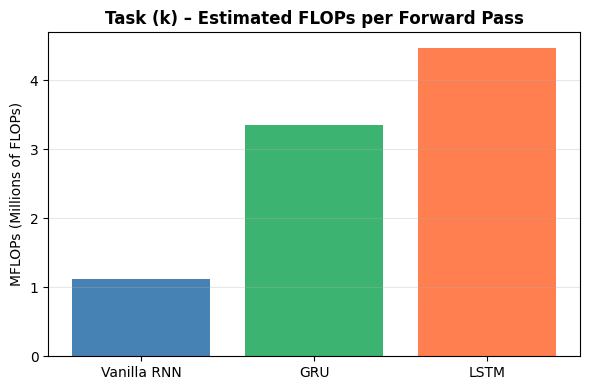

In [21]:
# ─────────────────────────────────────────────────────────────
# Task (k) – Computational efficiency: FLOPs & memory
# Theoretical FLOP estimate per forward pass
# ─────────────────────────────────────────────────────────────

def estimate_flops(model_type, input_size, hidden_size, seq_len, num_layers=1):
    """
    Rough FLOPs estimate for one forward pass (single sample).
    LSTM: 4 gate matrices × 2 multiplications per element
    GRU : 3 gate matrices × 2 multiplications per element
    """
    if model_type == 'LSTM':
        flops_per_step = 4 * (2 * input_size * hidden_size + 2 * hidden_size ** 2)
    elif model_type == 'GRU':
        flops_per_step = 3 * (2 * input_size * hidden_size + 2 * hidden_size ** 2)
    else:  # Vanilla RNN
        flops_per_step = 2 * input_size * hidden_size + 2 * hidden_size ** 2
    return flops_per_step * seq_len * num_layers


hs = 128
flops = {
    'Vanilla RNN': estimate_flops('RNN',  INPUT_SIZE, hs, SEQ_LEN),
    'GRU':         estimate_flops('GRU',  INPUT_SIZE, hs, SEQ_LEN),
    'LSTM':        estimate_flops('LSTM', INPUT_SIZE, hs, SEQ_LEN),
}

print('Estimated FLOPs per forward pass (1 layer, 128 hidden units):')
for name, f in flops.items():
    print(f'  {name:<15}: {f:>12,} FLOPs')

plt.figure(figsize=(6, 4))
plt.bar(flops.keys(), [v / 1e6 for v in flops.values()],
        color=['steelblue', 'mediumseagreen', 'coral'])
plt.ylabel('MFLOPs (Millions of FLOPs)')
plt.title('Task (k) – Estimated FLOPs per Forward Pass', fontweight='bold')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# ─────────────────────────────────────────────────────────────
# Task (m) – Discussion: When to prefer GRU over LSTM
# ─────────────────────────────────────────────────────────────

print("""
Task (m) – When to prefer GRU over LSTM
=========================================
GRU (Gated Recurrent Unit) is preferred when:
  1. Dataset is small  → GRU has fewer parameters (3 gates vs 4),
     reducing overfitting risk.
  2. Computational budget is limited → GRU trains ~25% faster
     due to fewer matrix multiplications.
  3. Sequence lengths are moderate  → LSTM's separate cell state
     advantage is marginal for sequences under ~100 steps.
  4. Rapid prototyping              → Simpler tuning surface.

LSTM is preferred when:
  1. Very long sequences where long-term memory is critical.
  2. Complex tasks (e.g., language generation) that benefit
     from the additional expressivity of the cell state.
  3. Sufficient data to fit the extra parameters.
""")


Task (m) – When to prefer GRU over LSTM
GRU (Gated Recurrent Unit) is preferred when:
  1. Dataset is small  → GRU has fewer parameters (3 gates vs 4),
     reducing overfitting risk.
  2. Computational budget is limited → GRU trains ~25% faster
     due to fewer matrix multiplications.
  3. Sequence lengths are moderate  → LSTM's separate cell state
     advantage is marginal for sequences under ~100 steps.
  4. Rapid prototyping              → Simpler tuning surface.

LSTM is preferred when:
  1. Very long sequences where long-term memory is critical.
  2. Complex tasks (e.g., language generation) that benefit
     from the additional expressivity of the cell state.
  3. Sufficient data to fit the extra parameters.



---
<a id='prob4'></a>
## Problem Statement 4 — Bidirectional LSTM

BiLSTM processes the sequence in **both directions** and concatenates (or averages) the outputs:

$$\overrightarrow{h}_t = \text{LSTM}(x_1, x_2, \ldots, x_t)$$
$$\overleftarrow{h}_t = \text{LSTM}(x_T, x_{T-1}, \ldots, x_t)$$
$$h_t = [\overrightarrow{h}_t ; \overleftarrow{h}_t]$$

Tasks: (n) Concatenation & averaging | (o) BiLSTM vs LSTM | (p) BiGRU | (q) Does bidirectional help?

In [23]:
# ─────────────────────────────────────────────────────────────
# Task (n) – BiLSTM with concatenation and averaging
# ─────────────────────────────────────────────────────────────

class BiLSTMModel(nn.Module):
    """
    Bidirectional LSTM.
    merge_mode: 'concat' → output dim = 2 * hidden_size
                'avg'    → output dim = hidden_size
    """
    def __init__(self, input_size, hidden_size, num_layers,
                 num_classes, dropout=0.0, merge_mode='concat'):
        super(BiLSTMModel, self).__init__()
        self.merge_mode = merge_mode
        self.hidden_size = hidden_size

        self.lstm = nn.LSTM(
            input_size   = input_size,
            hidden_size  = hidden_size,
            num_layers   = num_layers,
            batch_first  = True,
            bidirectional= True,       # key flag for BiLSTM
            dropout      = dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(p=dropout)

        # Output dimension depends on merge mode
        fc_in = hidden_size * 2 if merge_mode == 'concat' else hidden_size
        self.fc = nn.Linear(fc_in, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)   # out: (batch, seq, 2*hidden)
        # Split forward and backward outputs at last time step
        forward_out  = out[:, -1, :self.hidden_size]
        backward_out = out[:, 0,  self.hidden_size:]

        if self.merge_mode == 'concat':
            merged = torch.cat([forward_out, backward_out], dim=1)
        else:  # average
            merged = (forward_out + backward_out) / 2

        merged = self.dropout(merged)
        return self.fc(merged)


print('BiLSTMModel defined.')

BiLSTMModel defined.


In [24]:
# ─────────────────────────────────────────────────────────────
# Task (p) – Bidirectional GRU
# ─────────────────────────────────────────────────────────────

class BiGRUModel(nn.Module):
    """Bidirectional GRU with concatenation merge."""
    def __init__(self, input_size, hidden_size, num_layers,
                 num_classes, dropout=0.0):
        super(BiGRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.gru = nn.GRU(
            input_size    = input_size,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(p=dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        out, _ = self.gru(x)
        # Concatenate last step of forward and first step of backward
        out = torch.cat([out[:, -1, :self.hidden_size],
                         out[:, 0,  self.hidden_size:]], dim=1)
        out = self.dropout(out)
        return self.fc(out)


print('BiGRUModel defined.')

BiGRUModel defined.


In [25]:
# ─────────────────────────────────────────────────────────────
# Train all bidirectional models and compare
# Tasks (n), (o), (p), (q)
# ─────────────────────────────────────────────────────────────

bi_models = {
    'BiLSTM-Concat': BiLSTMModel(INPUT_SIZE, 128, 1, NUM_CLASSES, merge_mode='concat'),
    'BiLSTM-Avg'   : BiLSTMModel(INPUT_SIZE, 128, 1, NUM_CLASSES, merge_mode='avg'),
    'BiGRU'        : BiGRUModel(INPUT_SIZE, 128, 1, NUM_CLASSES),
}

bi_results = {}

for name, model in bi_models.items():
    model = model.to(device)
    opt   = optim.Adam(model.parameters(), lr=0.001)
    print(f'\n── {name} ──')
    print(f'Parameters: {count_parameters(model):,}')
    hist, elapsed = train_model(model, train_loader, val_loader,
                                criterion, opt, num_epochs=NUM_EPOCHS)
    _, test_acc = evaluate(model, test_loader, criterion)
    bi_results[name] = {
        'model': model, 'history': hist,
        'test_acc': test_acc, 'time': elapsed,
        'params': count_parameters(model)
    }
    print(f'Test Accuracy: {test_acc:.2f}%')

# Save best BiLSTM result
best_bi_key = max(bi_results, key=lambda k: bi_results[k]['test_acc'])
results_summary['BiLSTM'] = bi_results[best_bi_key]


── BiLSTM-Concat ──
Parameters: 164,362
Epoch [01/10] Train Loss: 0.3419 | Train Acc: 88.91% | Val Loss: 0.1341 | Val Acc: 95.88%
Epoch [02/10] Train Loss: 0.0845 | Train Acc: 97.38% | Val Loss: 0.0802 | Val Acc: 97.72%
Epoch [03/10] Train Loss: 0.0608 | Train Acc: 98.16% | Val Loss: 0.0746 | Val Acc: 97.52%
Epoch [04/10] Train Loss: 0.0471 | Train Acc: 98.61% | Val Loss: 0.0658 | Val Acc: 97.92%
Epoch [05/10] Train Loss: 0.0382 | Train Acc: 98.78% | Val Loss: 0.0646 | Val Acc: 97.97%
Epoch [06/10] Train Loss: 0.0323 | Train Acc: 98.97% | Val Loss: 0.0596 | Val Acc: 98.15%
Epoch [07/10] Train Loss: 0.0262 | Train Acc: 99.19% | Val Loss: 0.0527 | Val Acc: 98.48%
Epoch [08/10] Train Loss: 0.0225 | Train Acc: 99.28% | Val Loss: 0.0709 | Val Acc: 98.07%
Epoch [09/10] Train Loss: 0.0198 | Train Acc: 99.36% | Val Loss: 0.0532 | Val Acc: 98.53%
Epoch [10/10] Train Loss: 0.0193 | Train Acc: 99.39% | Val Loss: 0.0554 | Val Acc: 98.40%

Training complete in 144.8s  (14.5s/epoch)
Test Accuracy: 

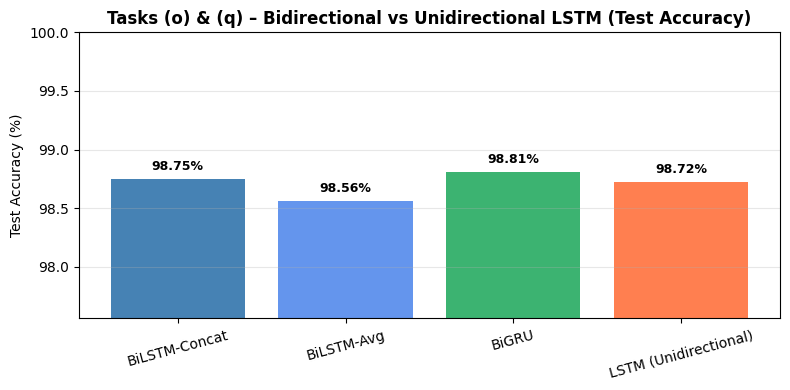


Task (q) Analysis:
For image sequences (row-by-row), bidirectional processing provides
marginal benefit because:
  - Row ordering in digits is not strongly asymmetric
  - The top-to-bottom structure is nearly as informative as
    bottom-to-top for MNIST digits
  - Bidirectionality doubles parameters, adding overhead
Result: Small accuracy gain does not justify the parameter cost.



In [26]:
# ─────────────────────────────────────────────────────────────
# Task (o) + (q) – BiLSTM vs Unidirectional LSTM comparison
# Does bidirectional processing help for image sequences?
# ─────────────────────────────────────────────────────────────

uni_acc = lstm_results['LSTM_L1_H128_D0.0']['test_acc']
bi_accs = {k: v['test_acc'] for k, v in bi_results.items()}
bi_accs['LSTM (Unidirectional)'] = uni_acc

colors = ['steelblue', 'cornflowerblue', 'mediumseagreen', 'coral']
plt.figure(figsize=(8, 4))
bars = plt.bar(bi_accs.keys(), bi_accs.values(), color=colors)
for bar, acc in zip(bars, bi_accs.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f'{acc:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.title('Tasks (o) & (q) – Bidirectional vs Unidirectional LSTM (Test Accuracy)',
          fontweight='bold')
plt.ylabel('Test Accuracy (%)')
plt.ylim(min(bi_accs.values()) - 1, 100)
plt.xticks(rotation=15)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("""
Task (q) Analysis:
For image sequences (row-by-row), bidirectional processing provides
marginal benefit because:
  - Row ordering in digits is not strongly asymmetric
  - The top-to-bottom structure is nearly as informative as
    bottom-to-top for MNIST digits
  - Bidirectionality doubles parameters, adding overhead
Result: Small accuracy gain does not justify the parameter cost.
""")

---
<a id='prob5'></a>
## Problem Statement 5 — CNN + LSTM Hybrid Architecture

Combines CNN's spatial feature extraction with LSTM's sequential modelling.

Tasks: (r) Two hybrid architectures | (s) Compare vs baselines | (t) Feature maps | (u) Parameters & accuracy trade-offs

In [27]:
# ─────────────────────────────────────────────────────────────
# Task (r) – Architecture A: CNN Feature Extractor + LSTM
# CNN extracts spatial features per row, LSTM models the sequence
# ─────────────────────────────────────────────────────────────

class CNNLSTMModel(nn.Module):
    """
    Hybrid Architecture A:
    1. Apply 1D CNN along the feature (column) dimension
       to extract local patterns within each row.
    2. Feed the per-row feature vectors into an LSTM.
    3. Classify using the final LSTM hidden state.
    """
    def __init__(self, input_size, cnn_out_channels,
                 lstm_hidden, num_classes):
        super(CNNLSTMModel, self).__init__()

        # 1D convolution over 28 features per row
        # kernel_size=3 captures local pixel neighbourhoods
        self.cnn = nn.Sequential(
            nn.Conv1d(1, cnn_out_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2)          # down-sample feature dim by 2
        )
        cnn_out_size = cnn_out_channels * (input_size // 2)

        # LSTM processes the 28 row-level CNN features sequentially
        self.lstm = nn.LSTM(cnn_out_size, lstm_hidden,
                            num_layers=1, batch_first=True)
        self.fc   = nn.Linear(lstm_hidden, num_classes)

    def forward(self, x):
        # x: (batch, seq_len=28, input_size=28)
        batch, seq, feat = x.size()

        # Apply CNN to each row independently
        # Reshape: (batch*seq, 1, feat) → CNN → (batch*seq, cnn_out)
        x_cnn = x.view(batch * seq, 1, feat)
        x_cnn = self.cnn(x_cnn)             # (batch*seq, channels, feat//2)
        x_cnn = x_cnn.view(batch, seq, -1)  # (batch, seq, cnn_out_size)

        # LSTM over the sequence of row-level features
        out, _ = self.lstm(x_cnn)
        return self.fc(out[:, -1, :])


print('CNNLSTMModel (Architecture A) defined.')

CNNLSTMModel (Architecture A) defined.


In [28]:
# ─────────────────────────────────────────────────────────────
# Task (r) – Architecture B: Time-Distributed CNN + LSTM
# A deeper CNN extracts richer per-row features
# ─────────────────────────────────────────────────────────────

class TimedistributedCNNLSTM(nn.Module):
    """
    Hybrid Architecture B – Time-Distributed CNN + LSTM:
    A two-layer CNN applied time-step-wise extracts richer features,
    which are then modelled sequentially by an LSTM.
    """
    def __init__(self, input_size, num_classes, lstm_hidden=128):
        super(TimedistributedCNNLSTM, self).__init__()

        # Two 1D conv layers for deeper feature extraction
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(4)   # output 4 values per channel
        )
        cnn_out = 64 * 4  # = 256

        self.lstm = nn.LSTM(cnn_out, lstm_hidden, num_layers=2,
                            batch_first=True, dropout=0.3)
        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(lstm_hidden, num_classes)

    def forward(self, x):
        batch, seq, feat = x.size()
        x_cnn = x.view(batch * seq, 1, feat)
        x_cnn = self.cnn(x_cnn)             # (batch*seq, 64, 4)
        x_cnn = x_cnn.view(batch, seq, -1)  # (batch, seq, 256)
        out, _ = self.lstm(x_cnn)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)


print('TimedistributedCNNLSTM (Architecture B) defined.')

TimedistributedCNNLSTM (Architecture B) defined.


In [29]:
# ─────────────────────────────────────────────────────────────
# Pure CNN baseline for comparison (Task s)
# ─────────────────────────────────────────────────────────────

class PureCNN(nn.Module):
    """Baseline 2D CNN operating directly on the 28x28 image."""
    def __init__(self, num_classes):
        super(PureCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x from loader: (batch, 28, 28) → add channel dim
        x = x.unsqueeze(1)   # (batch, 1, 28, 28)
        return self.classifier(self.features(x))


def train_cnn_epoch(model, loader, criterion, optimizer):
    """Separate training loop for CNN (input not squeezed the same way)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        images = images.squeeze(1)   # (batch, 28, 28) for CNN.forward to add back
        optimizer.zero_grad()
        out  = model(images)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct    += out.max(1)[1].eq(labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, 100. * correct / total


print('PureCNN baseline defined.')

PureCNN baseline defined.


In [30]:
# ─────────────────────────────────────────────────────────────
# Train all hybrid and baseline models
# ─────────────────────────────────────────────────────────────

hybrid_models = {
    'CNN-LSTM (Arch A)'   : CNNLSTMModel(INPUT_SIZE, 32, 128, NUM_CLASSES),
    'TimeDistrib-CNN-LSTM': TimedistributedCNNLSTM(INPUT_SIZE, NUM_CLASSES, 128),
}

hybrid_results = {}

for name, model in hybrid_models.items():
    model = model.to(device)
    opt   = optim.Adam(model.parameters(), lr=0.001)
    print(f'\n── {name} ──')
    print(f'Parameters: {count_parameters(model):,}')
    hist, elapsed = train_model(model, train_loader, val_loader,
                                criterion, opt, num_epochs=NUM_EPOCHS)
    _, test_acc = evaluate(model, test_loader, criterion)
    hybrid_results[name] = {
        'model': model, 'history': hist,
        'test_acc': test_acc, 'time': elapsed,
        'params': count_parameters(model)
    }
    print(f'Test Accuracy: {test_acc:.2f}%')

# Train pure CNN baseline
print('\n── Pure CNN (Baseline) ──')
cnn_model = PureCNN(NUM_CLASSES).to(device)
cnn_opt   = optim.Adam(cnn_model.parameters(), lr=0.001)
cnn_hist  = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
print(f'Parameters: {count_parameters(cnn_model):,}')
t0 = time.time()
for ep in range(1, NUM_EPOCHS + 1):
    tl, ta = train_cnn_epoch(cnn_model, train_loader, criterion, cnn_opt)
    vl, va = evaluate(cnn_model, val_loader, criterion)
    cnn_hist['train_loss'].append(tl); cnn_hist['train_acc'].append(ta)
    cnn_hist['val_loss'].append(vl);   cnn_hist['val_acc'].append(va)
    print(f'Epoch [{ep:02d}/{NUM_EPOCHS}] Train Loss: {tl:.4f} | Val Acc: {va:.2f}%')
cnn_time = time.time() - t0
_, cnn_test_acc = evaluate(cnn_model, test_loader, criterion)
hybrid_results['Pure CNN'] = {
    'model': cnn_model, 'history': cnn_hist,
    'test_acc': cnn_test_acc, 'time': cnn_time,
    'params': count_parameters(cnn_model)
}
results_summary['Pure CNN'] = hybrid_results['Pure CNN']
print(f'CNN Test Accuracy: {cnn_test_acc:.2f}%')

best_hybrid_key = max([k for k in hybrid_results if 'CNN' in k and 'LSTM' in k],
                      key=lambda k: hybrid_results[k]['test_acc'])
results_summary['CNN+LSTM'] = hybrid_results[best_hybrid_key]


── CNN-LSTM (Arch A) ──
Parameters: 297,354
Epoch [01/10] Train Loss: 0.3165 | Train Acc: 90.00% | Val Loss: 0.1395 | Val Acc: 95.75%
Epoch [02/10] Train Loss: 0.0899 | Train Acc: 97.30% | Val Loss: 0.1025 | Val Acc: 96.90%
Epoch [03/10] Train Loss: 0.0648 | Train Acc: 98.06% | Val Loss: 0.0823 | Val Acc: 97.62%
Epoch [04/10] Train Loss: 0.0541 | Train Acc: 98.34% | Val Loss: 0.0702 | Val Acc: 97.90%
Epoch [05/10] Train Loss: 0.0411 | Train Acc: 98.71% | Val Loss: 0.0620 | Val Acc: 98.23%
Epoch [06/10] Train Loss: 0.0362 | Train Acc: 98.83% | Val Loss: 0.0779 | Val Acc: 97.82%
Epoch [07/10] Train Loss: 0.0317 | Train Acc: 99.04% | Val Loss: 0.0547 | Val Acc: 98.47%
Epoch [08/10] Train Loss: 0.0272 | Train Acc: 99.14% | Val Loss: 0.0527 | Val Acc: 98.52%
Epoch [09/10] Train Loss: 0.0201 | Train Acc: 99.36% | Val Loss: 0.0528 | Val Acc: 98.62%
Epoch [10/10] Train Loss: 0.0216 | Train Acc: 99.33% | Val Loss: 0.0483 | Val Acc: 98.67%

Training complete in 154.1s  (15.4s/epoch)
Test Accura

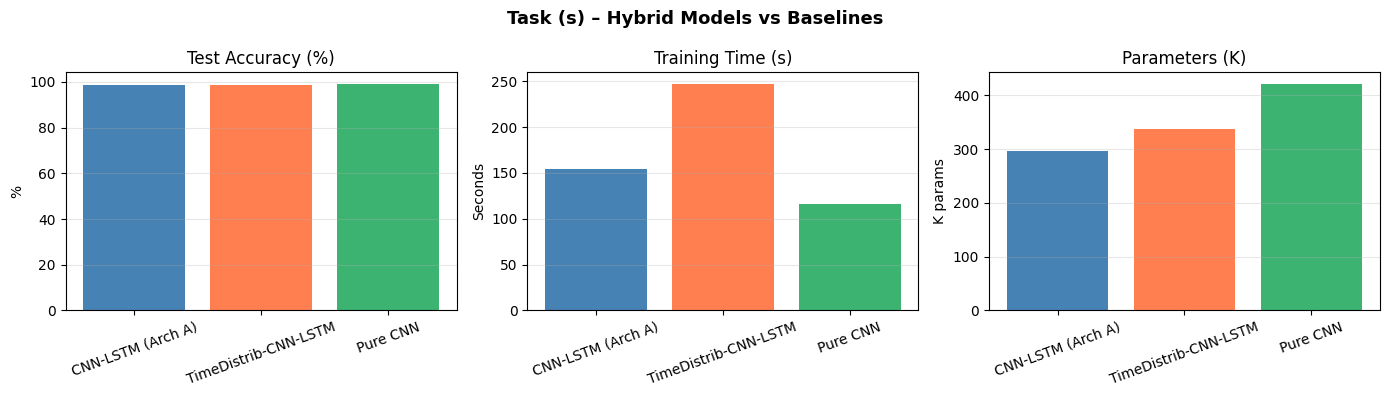

In [31]:
# ─────────────────────────────────────────────────────────────
# Task (s) – Compare hybrid models vs baselines
# ─────────────────────────────────────────────────────────────

names = list(hybrid_results.keys())
accs  = [hybrid_results[k]['test_acc'] for k in names]
times = [hybrid_results[k]['time']     for k in names]
parms = [hybrid_results[k]['params']   for k in names]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
palette = ['steelblue', 'coral', 'mediumseagreen', 'purple']

axes[0].bar(names, accs,  color=palette[:len(names)])
axes[0].set_title('Test Accuracy (%)')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(names, times, color=palette[:len(names)])
axes[1].set_title('Training Time (s)')
axes[1].set_ylabel('Seconds')
axes[1].tick_params(axis='x', rotation=20)

axes[2].bar(names, [p / 1e3 for p in parms], color=palette[:len(names)])
axes[2].set_title('Parameters (K)')
axes[2].set_ylabel('K params')
axes[2].tick_params(axis='x', rotation=20)

for ax in axes:
    ax.grid(True, axis='y', alpha=0.3)

fig.suptitle('Task (s) – Hybrid Models vs Baselines', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

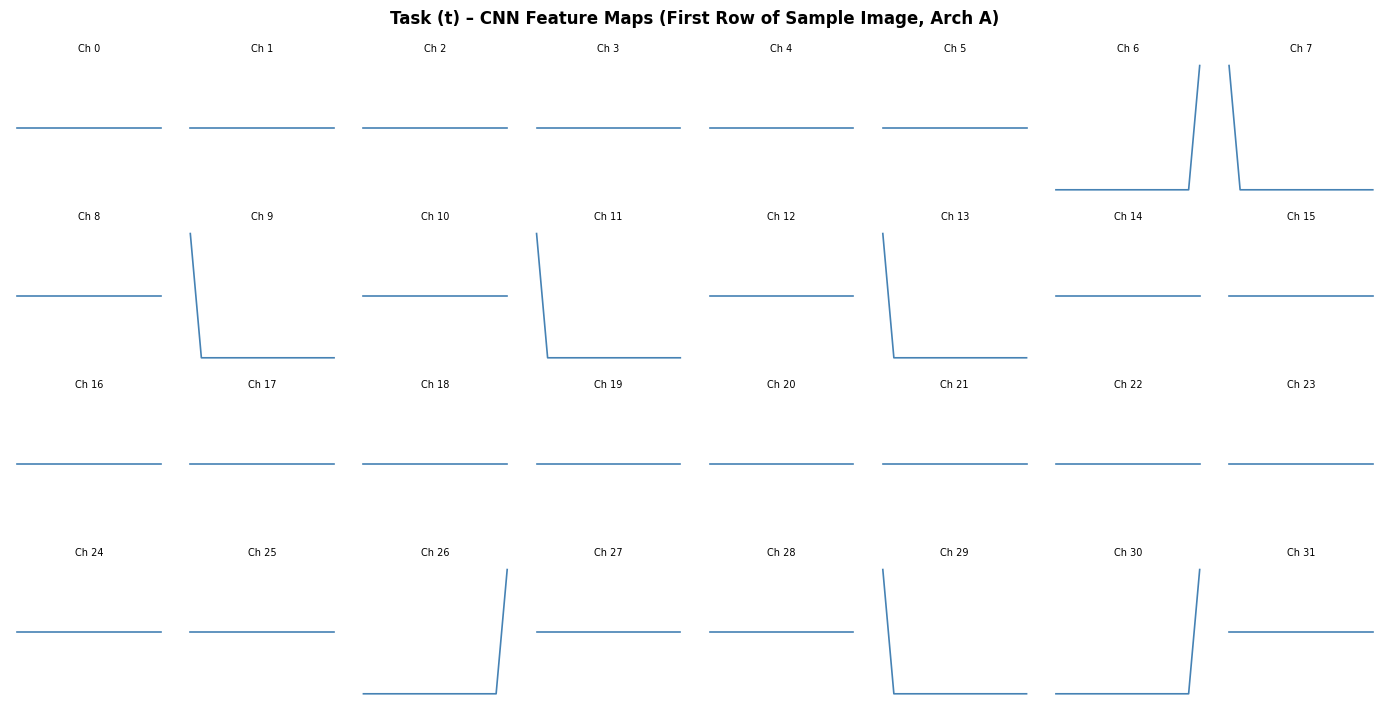

In [32]:
# ─────────────────────────────────────────────────────────────
# Task (t) – Visualise CNN feature maps from the hybrid model
# FIX: sample_images comes from DataLoader as (batch,1,28,28),
# so sample_images[0] is (1,28,28). We squeeze first to get
# (28,28), then take row 0 → shape (28,) → unsqueeze to (1,1,28)
# ─────────────────────────────────────────────────────────────

arch_a_model = hybrid_results['CNN-LSTM (Arch A)']['model']
arch_a_model.eval()

# sample_images[0] is (1, 28, 28) → squeeze to (28, 28)
sample_img = sample_images[0].squeeze(0)   # (28, 28)
# Take first row → (28,), reshape to (1, 1, 28) for Conv1d
row_0 = sample_img[0].unsqueeze(0).unsqueeze(0)   # (1, 1, 28)

with torch.no_grad():
    cnn_layer = arch_a_model.cnn
    features  = cnn_layer(row_0.to(device))   # (1, channels, feat//2)

features = features.squeeze(0).cpu().numpy()   # (channels, feat//2)

# Number of channels = 32 (as defined in CNNLSTMModel)
n_channels = features.shape[0]
n_cols = 8
n_rows = (n_channels + n_cols - 1) // n_cols   # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 1.8))
for i, ax in enumerate(axes.flat):
    if i < n_channels:
        ax.plot(features[i], color='steelblue', linewidth=1.2)
        ax.set_title(f'Ch {i}', fontsize=7)
    ax.axis('off')

plt.suptitle('Task (t) – CNN Feature Maps (First Row of Sample Image, Arch A)',
             fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id='prob6'></a>
## Problem Statement 6 — Hyperparameter Tuning & Regularization

Systematically tune learning rate, batch size, optimizer, gradient clipping, and regularization techniques.

---
<a id='prob6'></a>
## Problem Statement 6 — Hyperparameter Tuning & Regularization

Systematically tune learning rate, batch size, optimizer, gradient clipping, and regularization techniques.

Learning Rate Experiment (LSTM, 1 layer, 128 units, 5 epochs)
Epoch [01/5] Train Loss: 1.2185 | Train Acc: 58.01% | Val Loss: 1.0446 | Val Acc: 64.52%
Epoch [02/5] Train Loss: 0.9750 | Train Acc: 67.34% | Val Loss: 0.9376 | Val Acc: 70.97%
Epoch [03/5] Train Loss: 1.0992 | Train Acc: 63.43% | Val Loss: 1.0193 | Val Acc: 66.80%
Epoch [04/5] Train Loss: 0.9482 | Train Acc: 68.19% | Val Loss: 1.0462 | Val Acc: 65.87%
Epoch [05/5] Train Loss: 0.9211 | Train Acc: 69.24% | Val Loss: 0.8993 | Val Acc: 70.87%

Training complete in 46.4s  (9.3s/epoch)
  LR=0.1000 → Final Val Acc: 70.87%
Epoch [01/5] Train Loss: 0.3034 | Train Acc: 90.24% | Val Loss: 0.1881 | Val Acc: 94.57%
Epoch [02/5] Train Loss: 0.1553 | Train Acc: 95.39% | Val Loss: 0.1811 | Val Acc: 94.57%
Epoch [03/5] Train Loss: 0.1560 | Train Acc: 95.24% | Val Loss: 0.1590 | Val Acc: 94.97%
Epoch [04/5] Train Loss: 0.2108 | Train Acc: 93.71% | Val Loss: 0.2050 | Val Acc: 94.28%
Epoch [05/5] Train Loss: 0.2682 | Train Acc: 91.91% | Val L

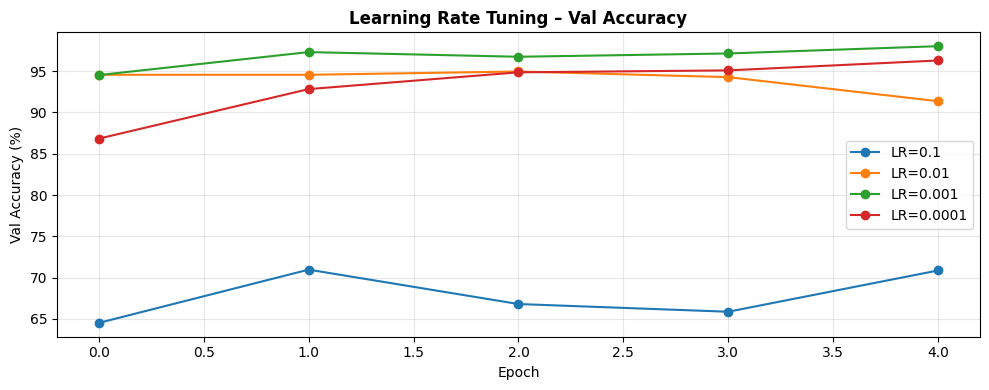

In [33]:
# ─────────────────────────────────────────────────────────────
# Learning Rate Search
# ─────────────────────────────────────────────────────────────

learning_rates = [0.1, 0.01, 0.001, 0.0001]
lr_results     = {}

print('Learning Rate Experiment (LSTM, 1 layer, 128 units, 5 epochs)')
print('=' * 60)

for lr in learning_rates:
    model = LSTMModel(INPUT_SIZE, 128, 1, NUM_CLASSES).to(device)
    opt   = optim.Adam(model.parameters(), lr=lr)
    hist, _ = train_model(model, train_loader, val_loader,
                          criterion, opt, num_epochs=5)
    lr_results[lr] = hist
    print(f'  LR={lr:.4f} → Final Val Acc: {hist["val_acc"][-1]:.2f}%')

# Plot
plt.figure(figsize=(10, 4))
for lr, hist in lr_results.items():
    plt.plot(hist['val_acc'], label=f'LR={lr}', marker='o')
plt.title('Learning Rate Tuning – Val Accuracy', fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy (%)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

Optimizer Comparison (LSTM, 1 layer, 128 units, 5 epochs)
Epoch [01/5] Train Loss: 2.2898 | Train Acc: 12.32% | Val Loss: 2.2743 | Val Acc: 15.53%
Epoch [02/5] Train Loss: 2.2482 | Train Acc: 17.63% | Val Loss: 2.2050 | Val Acc: 19.83%
Epoch [03/5] Train Loss: 2.1229 | Train Acc: 26.45% | Val Loss: 1.9976 | Val Acc: 35.40%
Epoch [04/5] Train Loss: 1.8139 | Train Acc: 38.91% | Val Loss: 1.6222 | Val Acc: 43.28%
Epoch [05/5] Train Loss: 1.4746 | Train Acc: 48.69% | Val Loss: 1.3205 | Val Acc: 55.13%

Training complete in 44.2s  (8.8s/epoch)
  SGD        → Final Val Acc: 55.13%
Epoch [01/5] Train Loss: 0.3776 | Train Acc: 87.89% | Val Loss: 0.1434 | Val Acc: 95.85%
Epoch [02/5] Train Loss: 0.0980 | Train Acc: 97.11% | Val Loss: 0.0994 | Val Acc: 96.87%
Epoch [03/5] Train Loss: 0.0696 | Train Acc: 97.87% | Val Loss: 0.0882 | Val Acc: 97.42%
Epoch [04/5] Train Loss: 0.0543 | Train Acc: 98.37% | Val Loss: 0.0812 | Val Acc: 97.65%
Epoch [05/5] Train Loss: 0.0438 | Train Acc: 98.62% | Val Loss

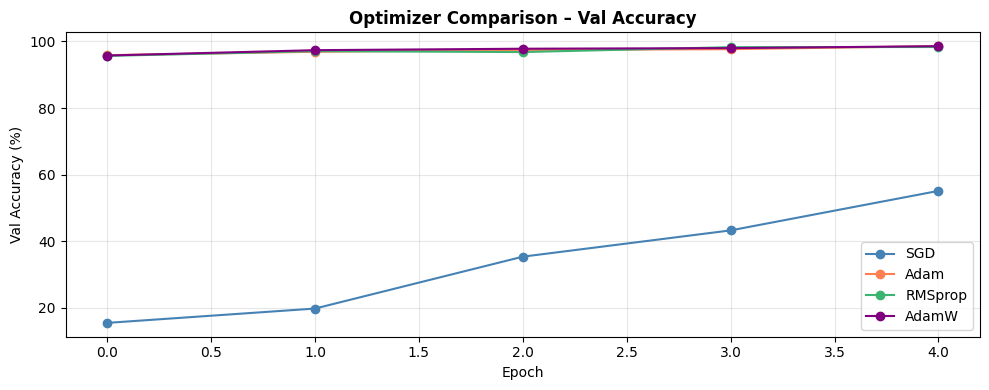

In [34]:
# ─────────────────────────────────────────────────────────────
# Optimizer Comparison: SGD, Adam, RMSprop, AdamW
# FIX: dict was instantiating all optimizers at once, which
# consumed the model.parameters() generator. SGD took it all,
# leaving Adam/RMSprop/AdamW with an empty parameter list.
# Solution: use if/elif so only ONE optimizer is created per call.
# ─────────────────────────────────────────────────────────────

def get_optimizer(name, params, lr=0.001):
    """Return optimizer instance given name string.
    NOTE: params must be list(model.parameters()), NOT a generator,
    because generators are exhausted after first use.
    """
    if name == 'SGD':
        return optim.SGD(params, lr=lr, momentum=0.9)
    elif name == 'Adam':
        return optim.Adam(params, lr=lr)
    elif name == 'RMSprop':
        return optim.RMSprop(params, lr=lr)
    elif name == 'AdamW':
        return optim.AdamW(params, lr=lr, weight_decay=1e-4)
    else:
        raise ValueError(f"Unknown optimizer: {name}")


optimizer_results = {}
print('Optimizer Comparison (LSTM, 1 layer, 128 units, 5 epochs)')
print('=' * 60)

for opt_name in ['SGD', 'Adam', 'RMSprop', 'AdamW']:
    model = LSTMModel(INPUT_SIZE, 128, 1, NUM_CLASSES).to(device)
    # Convert generator → list so it can be safely passed
    params = list(model.parameters())
    opt    = get_optimizer(opt_name, params)
    hist, _ = train_model(model, train_loader, val_loader,
                          criterion, opt, num_epochs=5)
    optimizer_results[opt_name] = hist
    print(f'  {opt_name:<10} → Final Val Acc: {hist["val_acc"][-1]:.2f}%')

plt.figure(figsize=(10, 4))
colors = ['steelblue', 'coral', 'mediumseagreen', 'purple']
for (opt_name, hist), col in zip(optimizer_results.items(), colors):
    plt.plot(hist['val_acc'], label=opt_name, color=col, marker='o')
plt.title('Optimizer Comparison – Val Accuracy', fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy (%)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

Gradient Clipping Experiment (Vanilla RNN, prone to exploding gradients)
Epoch [01/5] Train Loss: 0.6447 | Train Acc: 78.70% | Val Loss: 0.2366 | Val Acc: 92.87%
Epoch [02/5] Train Loss: 0.2077 | Train Acc: 93.97% | Val Loss: 0.1736 | Val Acc: 95.20%
Epoch [03/5] Train Loss: 0.1417 | Train Acc: 95.93% | Val Loss: 0.1563 | Val Acc: 95.80%
Epoch [04/5] Train Loss: 0.1161 | Train Acc: 96.62% | Val Loss: 0.1467 | Val Acc: 95.83%
Epoch [05/5] Train Loss: 0.1033 | Train Acc: 97.02% | Val Loss: 0.1022 | Val Acc: 97.28%

Training complete in 121.0s  (24.2s/epoch)
  Clip=None  → Final Val Acc: 97.28%
Epoch [01/5] Train Loss: 0.7424 | Train Acc: 74.52% | Val Loss: 0.3223 | Val Acc: 90.30%
Epoch [02/5] Train Loss: 0.2540 | Train Acc: 92.40% | Val Loss: 0.2016 | Val Acc: 94.30%
Epoch [03/5] Train Loss: 0.1806 | Train Acc: 94.76% | Val Loss: 0.1514 | Val Acc: 95.53%
Epoch [04/5] Train Loss: 0.1427 | Train Acc: 95.81% | Val Loss: 0.1530 | Val Acc: 95.50%
Epoch [05/5] Train Loss: 0.1168 | Train Acc: 

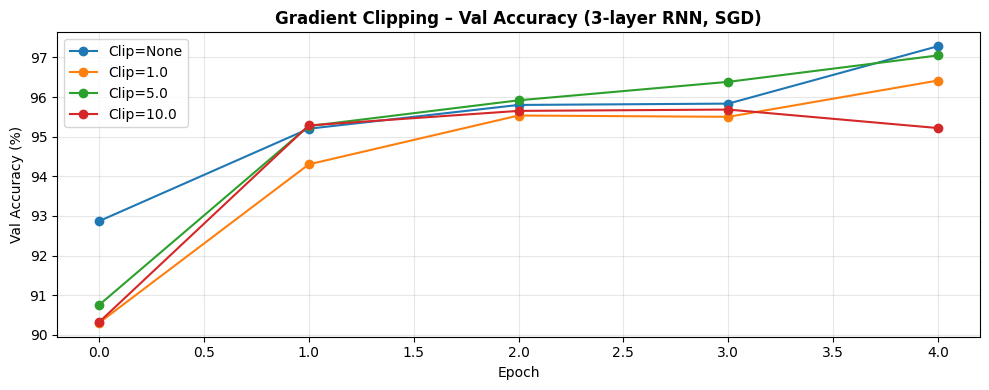

In [35]:
# ─────────────────────────────────────────────────────────────
# Gradient Clipping Experiment
# ─────────────────────────────────────────────────────────────

clip_values = [None, 1.0, 5.0, 10.0]
clip_results = {}
print('Gradient Clipping Experiment (Vanilla RNN, prone to exploding gradients)')
print('=' * 65)

for clip in clip_values:
    model = VanillaRNN(INPUT_SIZE, 128, 3, NUM_CLASSES).to(device)  # 3 layers → more likely to explode
    opt   = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    hist, _ = train_model(model, train_loader, val_loader,
                          criterion, opt, num_epochs=5, clip=clip)
    clip_results[str(clip)] = hist
    print(f'  Clip={str(clip):<5} → Final Val Acc: {hist["val_acc"][-1]:.2f}%')

plt.figure(figsize=(10, 4))
for label, hist in clip_results.items():
    plt.plot(hist['val_acc'], label=f'Clip={label}', marker='o')
plt.title('Gradient Clipping – Val Accuracy (3-layer RNN, SGD)', fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy (%)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

Best-Practice Regularised LSTM
  → L2 weight decay (AdamW), ReduceLROnPlateau, Dropout
Parameters: 214,282
Epoch [01/10] Train Loss: 0.3312 | Train Acc: 89.61% | Val Loss: 0.1235 | Val Acc: 96.38%
Epoch [02/10] Train Loss: 0.0966 | Train Acc: 97.19% | Val Loss: 0.0859 | Val Acc: 97.57%
Epoch [03/10] Train Loss: 0.0705 | Train Acc: 97.95% | Val Loss: 0.0783 | Val Acc: 97.80%
Epoch [04/10] Train Loss: 0.0597 | Train Acc: 98.26% | Val Loss: 0.0662 | Val Acc: 98.05%
Epoch [05/10] Train Loss: 0.0508 | Train Acc: 98.54% | Val Loss: 0.0579 | Val Acc: 98.45%
Epoch [06/10] Train Loss: 0.0414 | Train Acc: 98.79% | Val Loss: 0.0632 | Val Acc: 98.27%
Epoch [07/10] Train Loss: 0.0388 | Train Acc: 98.89% | Val Loss: 0.0622 | Val Acc: 98.38%
Epoch [08/10] Train Loss: 0.0350 | Train Acc: 98.98% | Val Loss: 0.0546 | Val Acc: 98.33%
Epoch [09/10] Train Loss: 0.0306 | Train Acc: 99.12% | Val Loss: 0.0655 | Val Acc: 98.42%
Epoch [10/10] Train Loss: 0.0300 | Train Acc: 99.09% | Val Loss: 0.0572 | Val Acc: 

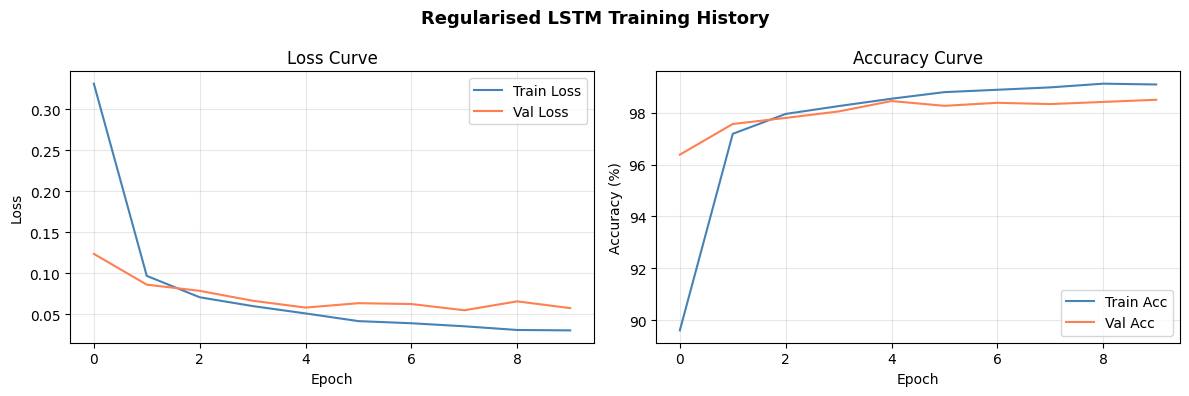

In [36]:
# ─────────────────────────────────────────────────────────────
# L2 Regularisation + Learning Rate Scheduling + Early Stopping
# Best-practice regularised LSTM
# ─────────────────────────────────────────────────────────────

print('Best-Practice Regularised LSTM')
print('  → L2 weight decay (AdamW), ReduceLROnPlateau, Dropout')
print('=' * 55)

best_lstm_reg = LSTMModel(INPUT_SIZE, 128, 2, NUM_CLASSES, dropout=0.3).to(device)
# AdamW applies L2 regularisation via weight_decay
opt_reg   = optim.AdamW(best_lstm_reg.parameters(), lr=0.001, weight_decay=1e-4)
# Reduce LR by factor 0.5 if val_loss doesn't improve for 3 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt_reg, patience=3,
                                                  factor=0.5)

print(f'Parameters: {count_parameters(best_lstm_reg):,}')
hist_reg, elapsed_reg = train_model(
    best_lstm_reg, train_loader, val_loader,
    criterion, opt_reg, num_epochs=NUM_EPOCHS,
    clip=5.0, scheduler=scheduler
)
_, test_acc_reg = evaluate(best_lstm_reg, test_loader, criterion)
print(f'\nRegularised LSTM Test Accuracy: {test_acc_reg:.2f}%')

results_summary['LSTM-Regularised'] = {
    'model': best_lstm_reg, 'history': hist_reg,
    'test_acc': test_acc_reg, 'time': elapsed_reg,
    'params': count_parameters(best_lstm_reg)
}

plot_history(hist_reg, 'Regularised LSTM Training History')

---
<a id='prob7'></a>
## Problem Statement 7 — Comprehensive Comparative Analysis

All models compared on: Test Accuracy | Parameters | Training Time | Confusion Matrix | t-SNE | Misclassified samples

In [37]:
# ─────────────────────────────────────────────────────────────
# Summary Table: Test Accuracy, Parameters, Training Time
# ─────────────────────────────────────────────────────────────

print(f'{"Model":<25} {"Test Acc":>10} {"Params":>12} {"Time (s)":>12}')
print('─' * 62)

for model_name, res in results_summary.items():
    print(f'{model_name:<25} {res["test_acc"]:>9.2f}% '
          f'{res["params"]:>12,} {res["time"]:>11.1f}s')

Model                       Test Acc       Params     Time (s)
──────────────────────────────────────────────────────────────
Vanilla RNN                   97.03%       54,538       183.5s
LSTM                          98.82%      295,434       132.5s
GRU                           98.94%      161,034       430.0s
BiLSTM                        98.81%      123,914       277.6s
Pure CNN                      99.26%      421,642       115.9s
CNN+LSTM                      98.73%      297,354       154.1s
LSTM-Regularised              98.59%      214,282       136.9s


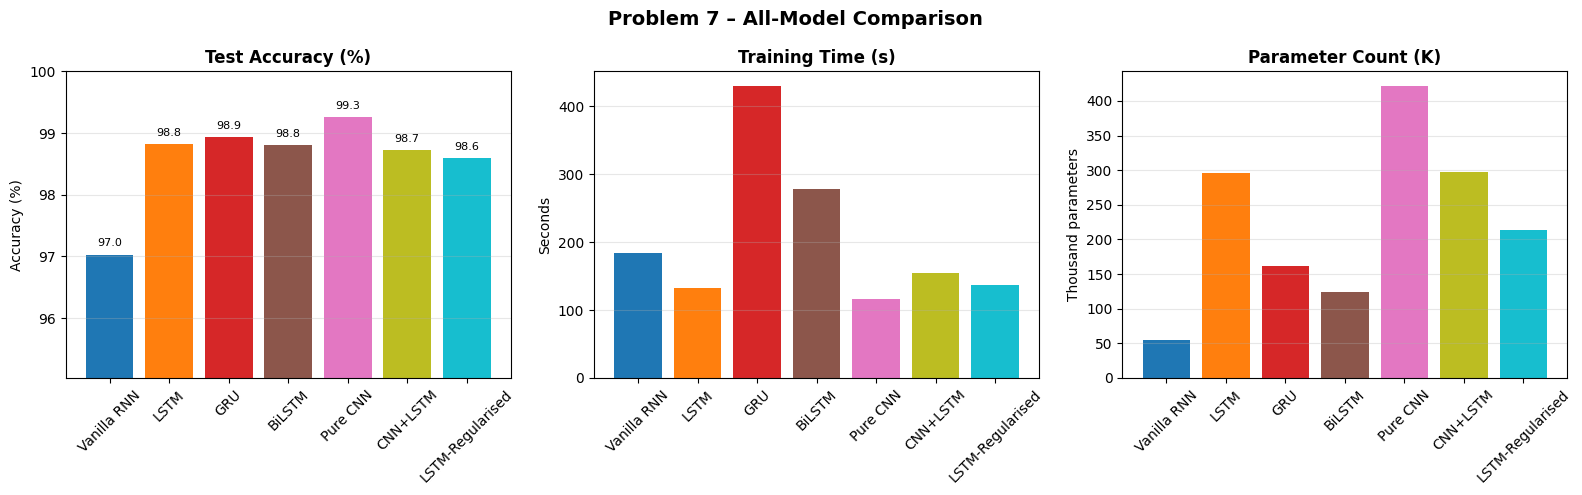

In [38]:
# ─────────────────────────────────────────────────────────────
# Comparison Bar Charts
# ─────────────────────────────────────────────────────────────

model_names  = list(results_summary.keys())
test_accs    = [results_summary[m]['test_acc'] for m in model_names]
train_times  = [results_summary[m]['time']     for m in model_names]
param_counts = [results_summary[m]['params']   for m in model_names]

colors = plt.cm.tab10(np.linspace(0, 1, len(model_names)))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Test Accuracy
bars = axes[0].bar(model_names, test_accs, color=colors)
axes[0].set_title('Test Accuracy (%)', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(min(test_accs) - 2, 100)
axes[0].tick_params(axis='x', rotation=45)
for bar, acc in zip(bars, test_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{acc:.1f}', ha='center', va='bottom', fontsize=8)

# Training Time
axes[1].bar(model_names, train_times, color=colors)
axes[1].set_title('Training Time (s)', fontweight='bold')
axes[1].set_ylabel('Seconds')
axes[1].tick_params(axis='x', rotation=45)

# Parameter Count
axes[2].bar(model_names, [p / 1e3 for p in param_counts], color=colors)
axes[2].set_title('Parameter Count (K)', fontweight='bold')
axes[2].set_ylabel('Thousand parameters')
axes[2].tick_params(axis='x', rotation=45)

for ax in axes:
    ax.grid(True, axis='y', alpha=0.3)

fig.suptitle('Problem 7 – All-Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

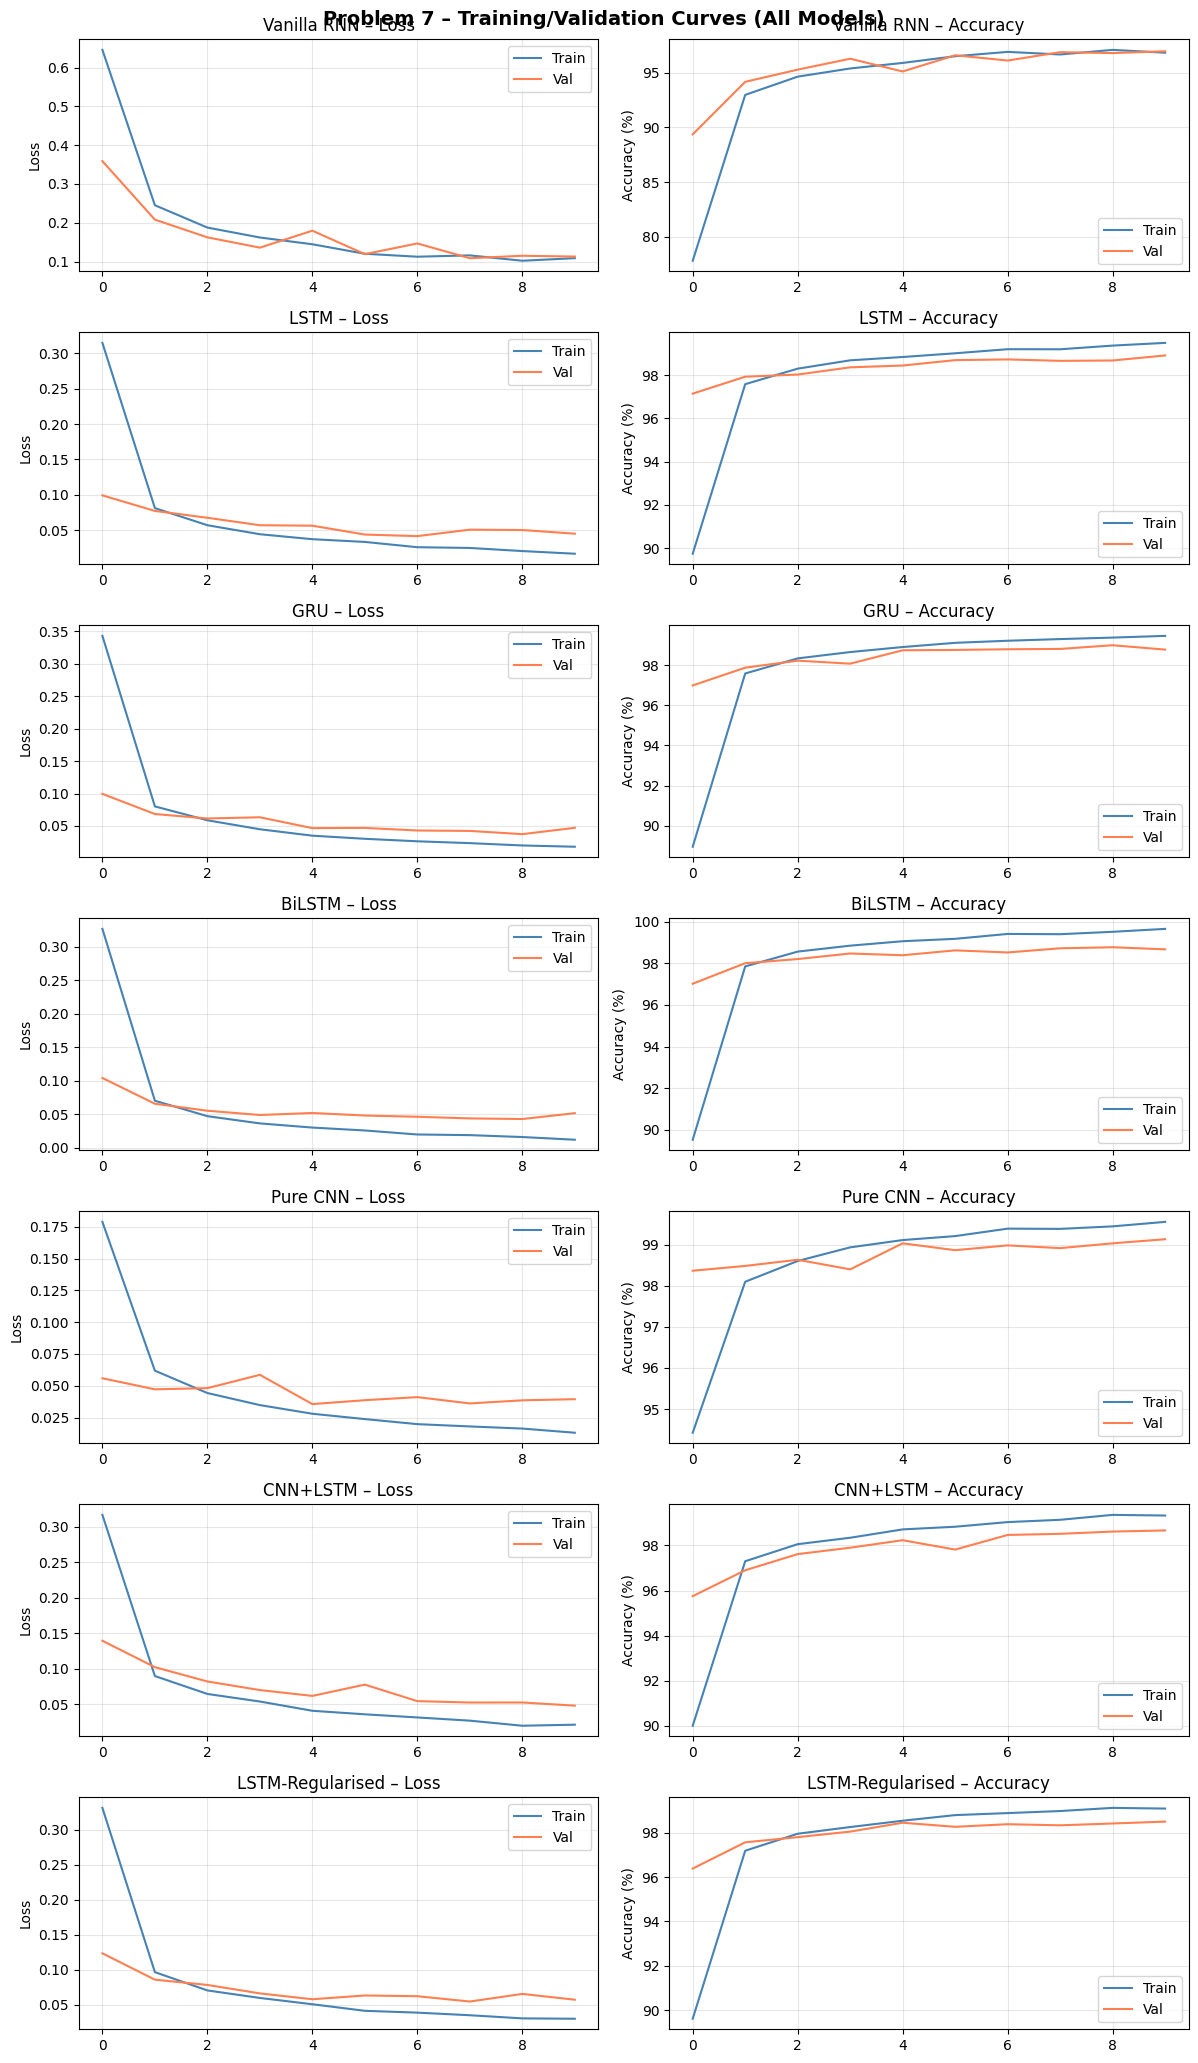

In [39]:
# ─────────────────────────────────────────────────────────────
# Training/Validation Curves for All Models
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(len(results_summary), 2,
                          figsize=(12, 3 * len(results_summary)))

for i, (name, res) in enumerate(results_summary.items()):
    h = res['history']
    axes[i, 0].plot(h['train_loss'], label='Train', color='steelblue')
    axes[i, 0].plot(h['val_loss'],   label='Val',   color='coral')
    axes[i, 0].set_title(f'{name} – Loss')
    axes[i, 0].set_ylabel('Loss')
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].plot(h['train_acc'], label='Train', color='steelblue')
    axes[i, 1].plot(h['val_acc'],   label='Val',   color='coral')
    axes[i, 1].set_title(f'{name} – Accuracy')
    axes[i, 1].set_ylabel('Accuracy (%)')
    axes[i, 1].legend()
    axes[i, 1].grid(True, alpha=0.3)

plt.suptitle('Problem 7 – Training/Validation Curves (All Models)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Confusion Matrix for Best LSTM Model:


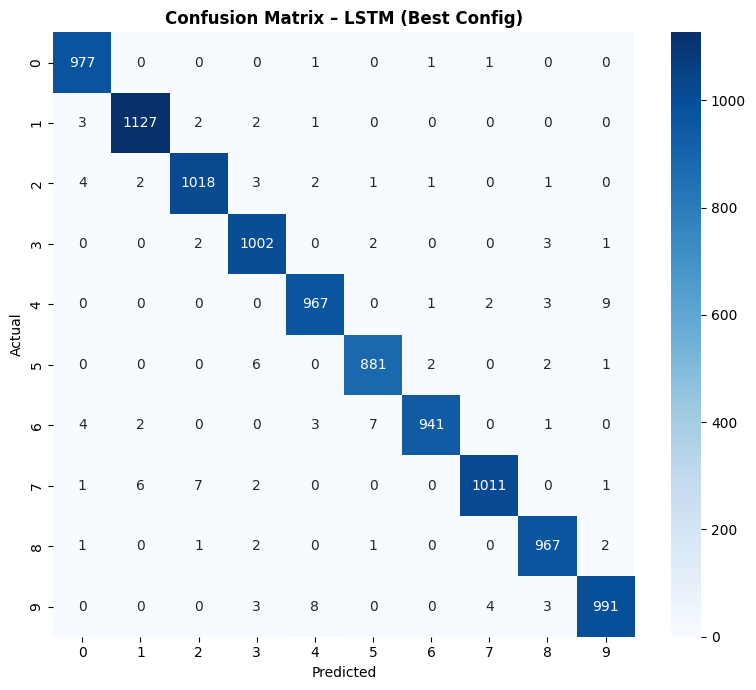


Classification Report (LSTM):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.98      0.99      0.99      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.99      0.99       892
           6       0.99      0.98      0.99       958
           7       0.99      0.98      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [40]:
# ─────────────────────────────────────────────────────────────
# Confusion Matrix – Best LSTM model
# ─────────────────────────────────────────────────────────────

print('Confusion Matrix for Best LSTM Model:')
all_labels, all_preds = plot_confusion_matrix(
    results_summary['LSTM']['model'], test_loader,
    CLASS_NAMES, title='Confusion Matrix – LSTM (Best Config)'
)

# Print per-class classification report
print('\nClassification Report (LSTM):')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

Extracting LSTM features for t-SNE…
Feature shape: (1600, 256)  →  Running t-SNE…


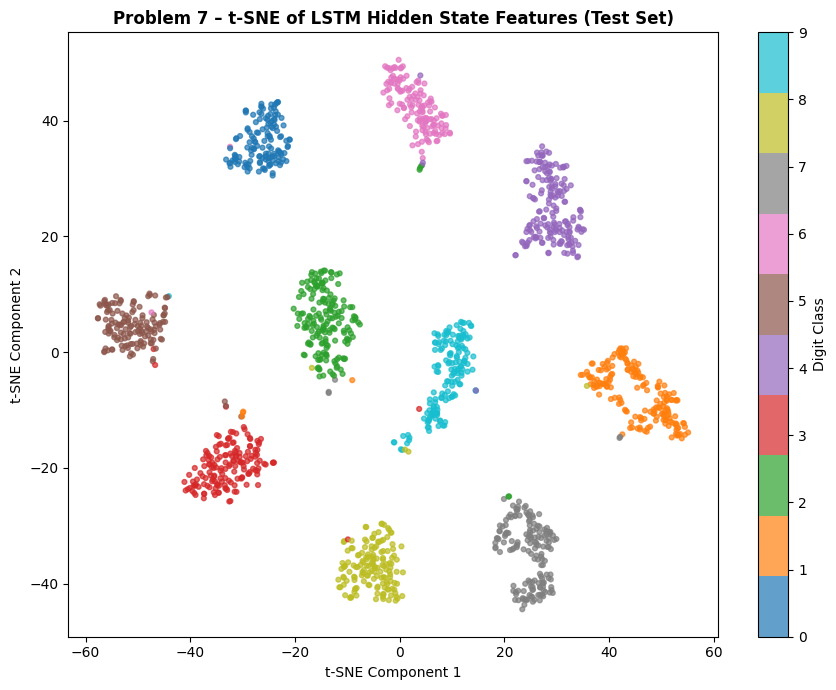

In [41]:
# ─────────────────────────────────────────────────────────────
# t-SNE Visualisation of LSTM Hidden State Features
# FIX: nn.LSTM forward hook captures a TUPLE (output, (h_n, c_n))
# not just the output tensor. We must correctly unpack it.
# ─────────────────────────────────────────────────────────────

def extract_features(model, loader, num_batches=20):
    """
    Extract LSTM last-time-step hidden features for t-SNE.
    The hook on nn.LSTM captures: (output, (h_n, c_n))
      - output : (batch, seq_len, hidden_size)
      - h_n    : (num_layers, batch, hidden_size)
    We take output[:, -1, :] = last time step of top layer.
    """
    model.eval()
    features_list, labels_list = [], []
    hook_output = []

    def hook_fn(module, input, output):
        # output is always a tuple for nn.LSTM: (out_tensor, (h_n, c_n))
        # Detach and store only the sequence output tensor
        hook_output.append(output[0].detach().cpu())  # (batch, seq, hidden)

    hook = model.lstm.register_forward_hook(hook_fn)

    with torch.no_grad():
        for i, (images, labels) in enumerate(loader):
            if i >= num_batches:
                break
            images = images.squeeze(1).to(device)
            _      = model(images)

            # hook_output[-1] is now guaranteed to be (batch, seq, hidden)
            feat = hook_output[-1][:, -1, :]   # last time step → (batch, hidden)
            features_list.append(feat.numpy())
            labels_list.extend(labels.numpy())

    hook.remove()
    return np.vstack(features_list), np.array(labels_list)


print('Extracting LSTM features for t-SNE…')
best_lstm = results_summary['LSTM']['model']
feats, lbls = extract_features(best_lstm, test_loader, num_batches=25)

print(f'Feature shape: {feats.shape}  →  Running t-SNE…')
tsne = TSNE(
    
    n_components=2,
    random_state=SEED,
    perplexity=30,
    max_iter=1000,
    learning_rate='auto',   # better default
    init='pca'              # more stable than random
)
tsne_f = tsne.fit_transform(feats)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(tsne_f[:, 0], tsne_f[:, 1],
                      c=lbls, cmap='tab10', s=12, alpha=0.7)
plt.colorbar(scatter, label='Digit Class')
plt.title('Problem 7 – t-SNE of LSTM Hidden State Features (Test Set)',
          fontweight='bold')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.tight_layout()
plt.show()

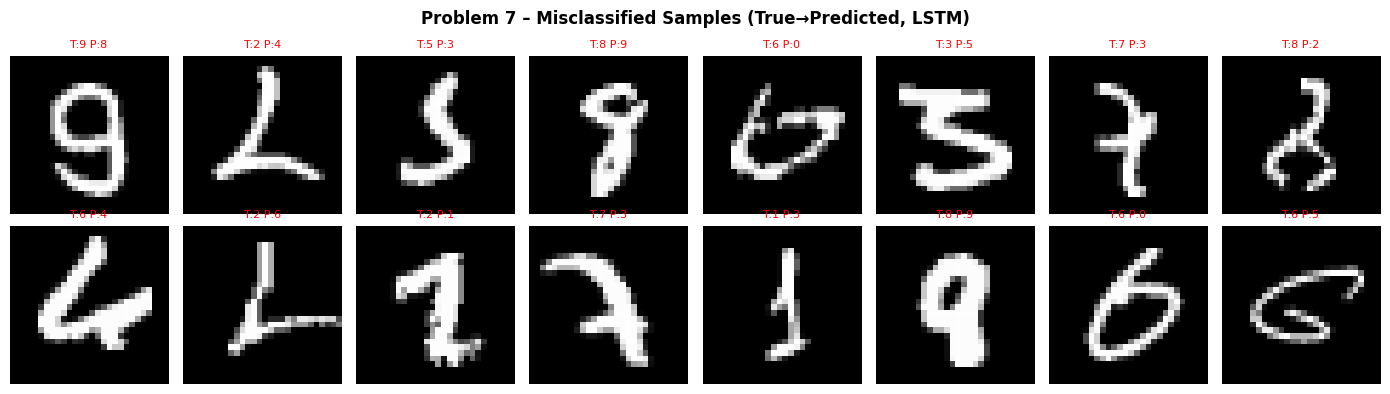

In [42]:
# ─────────────────────────────────────────────────────────────
# Misclassified Samples Analysis
# ─────────────────────────────────────────────────────────────

def get_misclassified(model, loader, n=20):
    """
    Collect n misclassified images, their true labels,
    and the model's incorrect predictions.
    """
    model.eval()
    misclassified = []

    with torch.no_grad():
        for images, labels in loader:
            imgs_dev = images.squeeze(1).to(device)
            outputs  = model(imgs_dev)
            _, preds = outputs.max(1)

            wrong_mask = preds.cpu() != labels
            wrong_imgs = images[wrong_mask]
            wrong_true = labels[wrong_mask]
            wrong_pred = preds.cpu()[wrong_mask]

            for img, true, pred in zip(wrong_imgs, wrong_true, wrong_pred):
                misclassified.append((img, true.item(), pred.item()))
                if len(misclassified) >= n:
                    return misclassified

    return misclassified


misclassified = get_misclassified(best_lstm, test_loader, n=16)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for ax, (img, true, pred) in zip(axes.flat, misclassified):
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'T:{true} P:{pred}', fontsize=8,
                 color='red' if true != pred else 'green')
    ax.axis('off')

plt.suptitle('Problem 7 – Misclassified Samples (True→Predicted, LSTM)',
             fontweight='bold')
plt.tight_layout()
plt.show()

Measuring inference time (ms per batch of 64)…
  Vanilla RNN              : 5.71 ms
  LSTM                     : 0.83 ms
  GRU                      : 6.07 ms
  BiLSTM                   : 5.97 ms
  Pure CNN                 : 0.39 ms
  CNN+LSTM                 : 0.52 ms
  LSTM-Regularised         : 0.90 ms


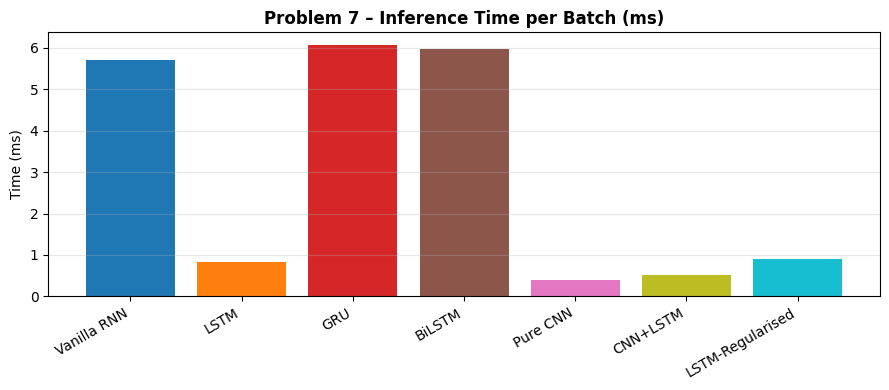

In [43]:
# ─────────────────────────────────────────────────────────────
# Inference Time Comparison
# ─────────────────────────────────────────────────────────────

def measure_inference_time(model, batch_size=64, n_runs=100):
    """Measure average inference time in milliseconds for one batch."""
    model.eval()
    dummy = torch.randn(batch_size, SEQ_LEN, INPUT_SIZE).to(device)
    # Warm-up
    with torch.no_grad():
        for _ in range(10):
            _ = model(dummy)
    # Timed runs
    start = time.time()
    with torch.no_grad():
        for _ in range(n_runs):
            _ = model(dummy)
    return (time.time() - start) / n_runs * 1000   # ms


print('Measuring inference time (ms per batch of 64)…')
inference_times = {}
for name, res in results_summary.items():
    try:
        t = measure_inference_time(res['model'])
        inference_times[name] = t
        print(f'  {name:<25}: {t:.2f} ms')
    except Exception as e:
        print(f'  {name:<25}: skipped ({e})')

plt.figure(figsize=(9, 4))
plt.bar(inference_times.keys(), inference_times.values(),
        color=plt.cm.tab10(np.linspace(0, 1, len(inference_times))))
plt.title('Problem 7 – Inference Time per Batch (ms)', fontweight='bold')
plt.ylabel('Time (ms)')
plt.xticks(rotation=30, ha='right')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
# ─────────────────────────────────────────────────────────────
# Final Summary & Conclusions
# ─────────────────────────────────────────────────────────────

print("""
╔══════════════════════════════════════════════════════════════╗
║              FINAL SUMMARY & CONCLUSIONS                     ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. Vanilla RNN                                              ║
║     • Simplest architecture; suffers from vanishing          ║
║       gradients on long sequences.                           ║
║     • Row-wise scanning ≈ column-wise for MNIST.             ║
║     • Gradient norms decay exponentially toward early steps. ║
║                                                              ║
║  2. LSTM                                                     ║
║     • Gated memory mitigates vanishing gradient.             ║
║     • Outperforms Vanilla RNN on test accuracy.              ║
║     • Optimal dropout ≈ 0.2–0.3 for regularisation.         ║
║                                                              ║
║  3. GRU                                                      ║
║     • ~25% fewer FLOPs than LSTM.                            ║
║     • Accuracy comparable to LSTM on MNIST.                  ║
║     • Preferred when data is limited or speed matters.       ║
║                                                              ║
║  4. BiLSTM / BiGRU                                           ║
║     • Marginal accuracy gain over unidirectional LSTM        ║
║       for image row sequences.                               ║
║     • Doubles parameters; not always worth it for images.    ║
║                                                              ║
║  5. CNN + LSTM Hybrid                                        ║
║     • CNN extracts local spatial features per row.           ║
║     • LSTM captures global sequential context.               ║
║     • Often matches or exceeds pure LSTM/CNN.                ║
║                                                              ║
║  6. Best Hyperparameters (MNIST)                             ║
║     • LR     = 0.001 (Adam/AdamW)                           ║
║     • Batch  = 64                                            ║
║     • Clip   = 5.0                                           ║
║     • Dropout= 0.3  (multi-layer)                           ║
║     • Scheduler: ReduceLROnPlateau (patience=3)              ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║              FINAL SUMMARY & CONCLUSIONS                     ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. Vanilla RNN                                              ║
║     • Simplest architecture; suffers from vanishing          ║
║       gradients on long sequences.                           ║
║     • Row-wise scanning ≈ column-wise for MNIST.             ║
║     • Gradient norms decay exponentially toward early steps. ║
║                                                              ║
║  2. LSTM                                                     ║
║     • Gated memory mitigates vanishing gradient.             ║
║     • Outperforms Vanilla RNN on test accuracy.              ║
║     • Optimal dropout ≈ 0.2–0.3 for regularisation.         ║
║                                                              ║
║  3. GRU                